# **NN-PU for 3D**

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
base_path = "drive/MyDrive/N-refinement/"
base_path2 = "drive/MyDrive/N-refinement/"

In [3]:
#@title install and import
# Python ≥ 3.5 is required
import sys
assert sys.version_info >= (3, 5)

# !pip install tensorflow==2.15.0
# !pip install tensorflow_probability==0.23.0

#@title import
import tensorflow as tf
# import tf-nightly as tf
assert tf.__version__ >= "2.0"
# assert tf.__version__ == "2.9.0"
import tensorflow_probability as tfp
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rcParams['mathtext.fontset'] = 'cm'

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "ann"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")



# import tensorflow as tf
from tensorflow import keras
import pandas as pd

from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.layers import Activation


import time

import pickle

print(tf.__version__)

!pip install ipython-autotime
%load_ext autotime

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

!nvidia-smi -L

print(device_name)

tf.keras.backend.set_floatx("float64")

2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.4 MB/s eta 0:00:00
Found GPU at: /device:GPU:0
GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-240f3297-2d6f-3fdb-0d99-3c34ec6d9bad)
/device:GPU:0
time: 1.6 s (started: 2026-05-21 17:15:42 +00:00)


In [4]:
#@title  setup folders
input_folder = 'Input_3Dbimat_Node396_Cell2662/'
load_folder = 'Input_3Dbimat_Node396_Cell2662/'

name_folder0 = base_path + input_folder
save_folder  = base_path2 + input_folder
name_index = name_folder0
name_folder20 = base_path2 + load_folder

# save folders
name_folder2 = name_folder20 + 'Results_40NR_4hidden_5bases/'
name_folder_final2 = name_folder2 + 'Final/'   # this is the folder from which you want to load some existing parameters.
name_folder = save_folder + 'Results_40NR_4hidden_5bases/'

# weight_folder = base_path + 'Input_L90NNRK_Node341_Cell1875/Results_8layerParam20NR_0.9act_1basis/Final/'

if os.path.isdir(name_folder) == False:
    os.mkdir(name_folder)
name_folder_final = name_folder + 'Final/'
if os.path.isdir(name_folder_final) == False:
    os.mkdir(name_folder_final)

time: 2.96 s (started: 2026-05-21 17:15:43 +00:00)


In [ ]:
#@title Load weights - commented. Reuse some parts when it is needed.

# #i_force_step = 0
# file_pkl = weight_folder+'_0_NNRK_model_NC'+'.pkl'
# open_file = open(file_pkl, "rb")
# wt_ld = pickle.load(open_file)
# open_file.close()

# # for i in range(0,len(model_NC.trainable_weights)):
# #     model_NC.trainable_weights[i].assign(wt_ld[i])

time: 331 µs (started: 2026-05-20 23:07:24 +00:00)


In [5]:
#@title Read input files
def read_dense(fname):
  A = tf.convert_to_tensor(np.float64(np.asarray(pd.read_csv(fname, header=None))))
  return A

def read_sparse(fname, size):
    A = pd.read_csv(fname, header=None, names=['idx1', 'idx2','val'])
    # Extract indices as a 2D NumPy array
    idx = A[['idx1', 'idx2']].to_numpy(dtype=np.int64)
    # Extract values as a 1D NumPy array
    val = A['val'].to_numpy(dtype=np.float64)
    # Construct the SparseTensor
    A_sp = tf.sparse.SparseTensor(indices=idx, values=val, dense_shape=size)
    return A_sp

def get_region(shp):
    # 1. Instantly replace all non-zero values with exactly 1.0
    new_values = tf.ones_like(shp.values)

    # 2. Reconstruct the sparse tensor
    shp_mask = tf.SparseTensor(
        indices=shp.indices,
        values=new_values,
        dense_shape=shp.dense_shape
    )

    # 3. Transpose natively
    return tf.sparse.transpose(shp_mask)
################################################################
X_cell = read_dense(name_index+'x.dat') # Domain integration points
X_smooth = read_dense(name_index+'x_smoothing.dat') # Domain smoothing points (cell edge points)
X_node = read_dense(name_index+'x_node.dat') # RK nodal points
xI_label = read_dense(name_index + 'xI_label.dat')
Vlabel = read_dense(name_index+'Vlabel.dat') # integration cell center material labels
print('Vlabel =', str(Vlabel.shape))
print('X_cell, X_smooth, X_node =', str(X_cell.shape), str(X_smooth.shape), str(X_node.shape))

WT = read_dense(name_index+'WT.dat') # Domain integration weights (Cell area)
WT_smooth = read_dense(name_index+'WT_smooth.dat')
WT_sum = tf.reduce_sum ( WT )
print(' ')
print('WT =', str(WT.shape))

n_cell = X_cell.shape[0]  # num of integration cells
n_smooth = X_smooth.shape[0]  # num of total smoothing points (cell edge points)
n_node = X_node.shape[0]  # num of RK nodes

print(' ')
print('[n_cell, n_smooth, n_node] =', [n_cell, n_smooth, n_node])



SHP_cell = read_sparse(name_index+'shp.dat', [n_cell, n_node]) # shp functions at cell centers

SHP_cell2 = read_sparse(name_index+'shp2.dat', [n_cell, n_cell]) # shp functions with two times support at cell centers (nodes are also cell centers)

SHP_smooth = read_sparse(name_index+'shp_smoothing.dat', [n_smooth, n_node]) # shp functions at cell edge smoothing points
# SHP_node = read_sparse(name_index+'shp_node.dat', [n_node, n_node]) # Nodal shp functions

print(' ')
print('SHP_cell, SHP_smooth, SHP2_cell =', str(SHP_cell.shape), str(SHP_smooth.shape),  str(SHP_cell2.shape))

P1_smooth = read_sparse(name_index+'P1.dat', [n_cell, n_smooth]) # smoothed x-derivative computation matrix
P2_smooth = read_sparse(name_index+'P2.dat', [n_cell, n_smooth]) # smoothed y-derivative computation matrix
P3_smooth = read_sparse(name_index+'P3.dat', [n_cell, n_smooth]) # smoothed y-derivative computation matrix
P_avg     = read_sparse(name_index+'P_avg.dat', [n_cell, n_smooth]) # cell averaging operator
# Integrity = read_dense(name_index+'integrity.dat') # Initial material integrity (0-1) array
print(' ')
print('P1_smooth, P2_smooth, P_avg  =', str(P1_smooth.shape), str(P2_smooth.shape), str(P_avg.shape))
# print('Integrity =', str(Integrity.shape))

# dmg_ref = 0. * Integrity  # initial damage

ns = np.int64(read_dense(name_index+'bc_info.dat'))
n_ebc_x = ns[0][0]
n_ebc_y = ns[0][1]
n_ebc_z = ns[0][2]
print(' ')
print('[n_ebc_x, n_ebc_y, n_ebc_z] =', [n_ebc_x, n_ebc_y, n_ebc_z])

CVC_int_x = read_sparse(name_index+'CVC_int_x.dat', [n_node, n_node-n_ebc_x])
CVC_ebc_x = read_sparse(name_index+'CVC_ebc_x.dat', [n_node, n_ebc_x])
CVC_int_y = read_sparse(name_index+'CVC_int_y.dat', [n_node, n_node-n_ebc_y])
CVC_ebc_y = read_sparse(name_index+'CVC_ebc_y.dat', [n_node, n_ebc_y])
CVC_int_z = read_sparse(name_index+'CVC_int_z.dat', [n_node, n_node-n_ebc_z])
CVC_ebc_z = read_sparse(name_index+'CVC_ebc_z.dat', [n_node, n_ebc_z])
print('CVC_ebc_x, CVC_ebc_y, CVC_ebc_z =', str(CVC_ebc_x.shape), str(CVC_ebc_y.shape), str(CVC_ebc_z.shape) )
print('CVC_int_x, CVC_int_y, CVC_int_z =', str(CVC_int_x.shape), str(CVC_int_y.shape), str(CVC_int_z.shape) )

# Read in initial value of the RK coefficients (solved by Kd=f matrix equation and scaled by dscaling factor)
dx_int_initial = np.float64(read_dense(name_index + 'dx_init.dat'))
dy_int_initial = np.float64(read_dense(name_index + 'dy_init.dat'))
dz_int_initial = np.float64(read_dense(name_index + 'dz_init.dat'))
print('dx_int_ini, dy_int_ini =', str(dx_int_initial.shape), str(dy_int_initial.shape))

# Read in the NN activition indicator
# NN_actv_init = np.float64(read_dense(name_index + 'NN_actv.dat'))
# print('NN_activation_init = ', str(NN_actv_init.shape))

#### for orthogolization
M_c = read_sparse(name_index+'M_c.dat', [n_node, n_node]) # shp_cell'*diag(A_cell)*shp_cell
M_s = read_sparse(name_index+'M_s.dat', [n_node, n_node])# shp_smoothing'*diag(L_edge)*shp_smoothing
print('')
print('M_c =', str(M_c.shape))

region = get_region(SHP_smooth)
# region =  read_sparse(name_index+'region.dat', [n_node, n_smooth])
print(' ')
print('region =', str(region.shape))


region_cell = get_region(SHP_cell)
# region_cell = read_sparse(name_index+'region_cell.dat', [n_node, n_cell])
print('region_cell =', str(region_cell.shape))


# Get minimum and maximum points

x_min = min(np.transpose(X_smooth)[0])
y_min = min(np.transpose(X_smooth)[1])
z_min = min(np.transpose(X_smooth)[2])
x_max = max(np.transpose(X_smooth)[0])
y_max = max(np.transpose(X_smooth)[1])
z_max = max(np.transpose(X_smooth)[2])
print(' ')
print('[x_min, x_max] =', [x_min, x_max])
print('[y_min, y_max] =', [y_min, y_max])
print('[z_min, z_max] =', [z_min, z_max])

Vlabel = (2662, 1)
X_cell, X_smooth, X_node = (2662, 3) (9696, 3) (396, 3)
 
WT = (2662, 1)
 
[n_cell, n_smooth, n_node] = [2662, 9696, 396]
 
SHP_cell, SHP_smooth, SHP2_cell = (2662, 396) (9696, 396) (2662, 2662)
 
P1_smooth, P2_smooth, P_avg  = (2662, 9696) (2662, 9696) (2662, 9696)
 
[n_ebc_x, n_ebc_y, n_ebc_z] = [np.int64(1), np.int64(72), np.int64(2)]
CVC_ebc_x, CVC_ebc_y, CVC_ebc_z = (396, 1) (396, 72) (396, 2)
CVC_int_x, CVC_int_y, CVC_int_z = (396, 395) (396, 324) (396, 394)
dx_int_ini, dy_int_ini = (395, 1) (324, 1)

M_c = (396, 396)
 
region = (396, 9696)
region_cell = (396, 2662)
 
[x_min, x_max] = [np.float64(-0.25), np.float64(0.25)]
[y_min, y_max] = [np.float64(-0.5), np.float64(0.5)]
[z_min, z_max] = [np.float64(-0.25), np.float64(0.25)]
time: 17.6 s (started: 2026-05-21 17:15:46 +00:00)


In [6]:
#@title Parameters
# nHL: number of hidden layers in NN enrichments
# nNR: number of neurons in each hidden layer
# actv: activation functions in each hidden layer

nHL, nNR, actv = 5, [40, 40, 40, 40, 5], ['elu','elu','elu','elu','elu']

n_NC = nNR[nHL-1]   # number of neurons at the last layer. This is number of NN enrichment functions
print('n_NC = ', n_NC)

sum_NC = np.ones((n_NC, 1), dtype=np.float64)
print('sum_NC.shape = ', sum_NC.shape)

# figure size for plot
Figure_Size = (10,8.3)

# constant applied EBC
gy_ebc = 0.01

##################################################################
# material properties
Em = 10400   # MPa, N/mm^2
num = .3

Ei = 52000   # MPa, N/mm^2
nui = .3

E = np.where(Vlabel == 0, Em, Ei)
nu = np.where(Vlabel == 0, num, nui)

mat_mu  = E / 2. / (1.+nu)
mat_lam = E*nu / (1.+nu)/(1.-2.*nu)


# print('E, nu = ', E, nu)
# print('mat_lam, mat_mu  = ', mat_lam, mat_mu)

mat_energy_scaling_ref = (x_max-x_min)*(y_max-y_min)*(z_max-z_min) / max(E)
print('mat_energy_scaling_ref  = ', mat_energy_scaling_ref)

n_NC =  5
sum_NC.shape =  (5, 1)
mat_energy_scaling_ref  =  [4.80769231e-06]
time: 16.5 ms (started: 2026-05-21 17:16:04 +00:00)


In [7]:
#@title a function for trisurf plot
print('Plot_Trisurf(x,y,z,figsize=(10,10),z_lim=[0,1])')
def Plot_Trisurf(x,y,z,figsize=(10,10),z_lim=[z_min,z_max], save_fig=0, fig_path='', show_fig=1):
    fig = plt.figure(figsize=figsize)
    ax  = plt.axes(projection = '3d', proj_type = 'ortho')
    # ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))
    surf = ax.plot_trisurf(x,y,z, \
                  cmap = plt.get_cmap('jet'), \
                  edgecolor='none')#,linewidth=0.2)
    ax.view_init(azim=-90, elev=90)
    fig.colorbar(surf, shrink=0.5)
    ax.auto_scale_xyz([x_min, x_max], [y_min, y_max], z_lim)
    if save_fig==1:
      fig.savefig(fig_path, bbox_inches='tight')
    if show_fig==1:
      plt.show()
    if show_fig==0:
      plt.close(fig)

def Plot_3D_Slice(X, Y, Z, Values, z_slice=0.05, tolerance=0.01, save_fig=0, fig_path='', show_fig=1):
    # Filter nodes that are near the middle of the thickness
    mask = np.abs(Z - z_slice) < tolerance

    fig = plt.figure(figsize=(4, 4))
    # Use standard 2D scatter or trisurf since we are looking at a flat slice
    surf = plt.tripcolor(X[mask], Y[mask], Values[mask], cmap='jet')
    plt.colorbar(surf, label='Result Value')
    plt.title(f'Slice at z = {z_slice}')
    plt.axis('equal')
    if save_fig==1:
      fig.savefig(fig_path, bbox_inches='tight')
    if show_fig==1:
      plt.show()
    if show_fig==0:
      plt.close(fig)

# def Plot_3D_Slice_interp(X, Y, Z, Values, z_slice=0.05, tolerance=0.1, save_fig=0, fig_path='', show_fig=1):
# # 1. Safely flatten TF tensors to 1D CPU NumPy arrays
#     X = tf.reshape(X, [-1]).numpy()
#     Y = tf.reshape(Y, [-1]).numpy()
#     Z = tf.reshape(Z, [-1]).numpy()
#     Values = tf.reshape(Values, [-1]).numpy()

#     # 2. Create the dense, uniform 3D grid
#     xi = np.linspace(x_min, x_max, 50)
#     yi = np.linspace(y_min, y_max, 50)
#     zi = np.linspace(z_min, z_max, 50)

#     # Use indexing='ij' to maintain intuitive matrix coordinates
#     XI, YI, ZI_grid = np.meshgrid(xi, yi, zi, indexing='ij')

#     # 3. Interpolate ALL unstructured 3D data onto the 3D regular grid
#     # method='linear' creates a 3D convex hull. Points outside the hull become NaN.
#     VI = griddata((X, Y, Z), Values, (XI, YI, ZI_grid), method='linear')

#     # 4. Extract the slice WITHOUT needing a tolerance mask
#     # Find the index of the zi array that is closest to your desired z_slice
#     z_index = np.argmin(np.abs(zi - z_slice))
#     actual_z = zi[z_index]

#     # Slice the 3D arrays to get 2D arrays
#     x_slice = XI[:, :, z_index]
#     y_slice = YI[:, :, z_index]
#     v_slice = VI[:, :, z_index]

#     # 5. Plotting
#     fig = plt.figure(figsize=(5, 4))

#     # Plot the interpolated grid using contourf
#     surf = plt.contourf(x_slice, y_slice, v_slice, levels=50, cmap='jet')

#     plt.colorbar(surf, label='Result Value')
#     plt.title(f'3D Interpolated Slice at z = {actual_z:.4f}')
#     plt.axis('equal')

#     if save_fig == 1:
#         fig.savefig(fig_path, bbox_inches='tight')
#     if show_fig == 1:
#         plt.show()
#     else:
#         plt.close(fig)

def Plot_3D_Results(x, y, z, result_values, figsize=(4, 4), save_fig=0, fig_path='', show_fig=1, cmap = 'Reds'):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # c is the result (stress/strain), x,y,z are coordinates
    p = ax.scatter(x, y, z, c=result_values, cmap=cmap, s=10, alpha=0.3)

    fig.colorbar(p, label='Magnitude', shrink=0.5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    ax.set_box_aspect([1, 2, 1]) # Highlight the thinness
    if save_fig==1:
      fig.savefig(fig_path, bbox_inches='tight')
    if show_fig==1:
      plt.show()
    if show_fig==0:
      plt.close(fig)

Plot_Trisurf(x,y,z,figsize=(10,10),z_lim=[0,1])
time: 2.82 ms (started: 2026-05-21 17:16:04 +00:00)


In [8]:
#@title some custom functions
def power_kernel(x, p=2, a=4., xi=1e-4):
    return K.pow( tf.nn.relu( 1 - (tf.math.sqrt(K.pow(x,2)+xi**2)-xi)/a) , p )

def exp_function(x):
    return tf.math.exp(x)

def tanh_function(x, c=1e-1):
    return tf.math.tanh(x/c)

def cubic_B_spline(x, a=1., xi=1e-4):
    # z = (tf.math.sqrt(K.pow(x,2)+xi**2) - xi) / a  # regularized absolute value
    z = x / a
    f1 = 1. - 6.*K.pow(z,2) + 6.*K.pow(z,3)
    f2 = 2.*K.pow((1.-z),3)
    return tf.nn.relu( f2 - tf.nn.relu(f2-f1) )

def soft_plus_jump(x, b=20.):
  # b is the continuity parameter beta. If no trainable beta is inputed, 20 will be used.
  return 2. * ( 1./b * ( tf.math.softplus(b*(x +.5)) - tf.math.softplus(b*(x -.5)) ) - .5 )

def parametric_softplus(x, b=1.):
  return 1./b * tf.math.softplus(b*x)

def smoothed_relu(x, c=1.):
  xx = tf.nn.relu(x)
  y0 = (.5*c)**2
  y1 = -tf.nn.relu(-((xx/c)**2-y0))
  y2 = tf.nn.relu(x-.5*c**2)
  return y0 + y1 + y2

# def skewed_kernel(x, p=4, a=1., xi=1e-4, c=1e-4):
#     phi1 = K.pow( tf.nn.relu( 1 - (tf.math.sqrt(K.pow(x,2)+xi**2)-xi)/a) , p )
#     phi2 = .5 + .5*tf.math.tanh(x/c)
#     return phi1*phi2

get_custom_objects().update({'power_kernel': Activation(power_kernel)})
get_custom_objects().update({'exp_function': Activation(exp_function)})
# get_custom_objects().update({'tanh_function': Activation(tanh_function)})


def constraint_min(a, a_min):
  return tf.nn.relu(a_min - a)**2
def constraint_max(a, a_max):
  return tf.nn.relu(a - a_max)**2
def constraint_minmax(a , a_min , a_max):
  return tf.nn.relu(a_min - a)**2  +  tf.nn.relu(a - a_max)**2

time: 4.49 ms (started: 2026-05-21 17:16:04 +00:00)


In [11]:
#@title Build NN
def get_nn_basis(nHL, nNR, actv):
  def build_dnn(nHL,nNR,actv,prefix):
      input = keras.layers.Input(shape=[3], name=prefix+'_input') # input layer
      HL_temp = input
      for i in range (0,nHL):
          if i == 0:
            a = 2./20.
          else:
            a = 1.
          # a = 1.
          HL_temp = keras.layers.Dense(nNR[i], activation=actv[i],
                            kernel_initializer=tf.keras.initializers.RandomUniform(minval=-a, maxval=a),
                                      name=prefix+'_HL_'+str(i))(HL_temp)
      output = HL_temp
      return input, output

  [input, output] = build_dnn(nHL,nNR,actv,'model_NC') # the output is the result of the last hidden layer
  model = keras.models.Model(inputs=[input], outputs=[output])
  return model

#######################

model_NC = get_nn_basis (nHL, nNR, actv)

# print("weights:", model_NC.weights)
# print("trainable_weights:", len(model_NC.trainable_weights))
# print("non_trainable_weights:", len(model_NC.non_trainable_weights))

print('model_NC  :')
model_NC.summary()
print(' ')
print('model_NC contains the neural corrections.')

model_NC  :


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model_NC_input (InputLayer)     │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_NC_HL_0 (Dense)           │ (None, 40)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_NC_HL_1 (Dense)           │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_NC_HL_2 (Dense)           │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_NC_HL_3 (Dense)           │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_NC_HL_4 (Dense)           │ (None, 5)              │           205 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,285 (41.29 KB)

 Trainable params: 5,285 (41.29 KB)

 Non-trainable params: 0 (0.00 B)

 
model_NC contains the neural corrections.
time: 829 ms (started: 2026-05-21 17:19:52 +00:00)


In [12]:
#@title Coefficient initilization

dx_int = tf.Variable(
    initial_value = np.float64(np.array([[.0]]*(n_node-n_ebc_x))),
    trainable=True)
dy_int = tf.Variable(
    initial_value = np.float64(np.array([[.0]]*(n_node-n_ebc_y))),
    trainable=True)
dz_int = tf.Variable(
    initial_value = np.float64(np.array([[.0]]*(n_node-n_ebc_z))),
    trainable=True)
# dx_int = tf.Variable(
#     initial_value = dx_int_initial,
#     trainable=True)
# dy_int = tf.Variable(
#     initial_value = dy_int_initial,
#     trainable=True)
dx_NN = tf.Variable(
    initial_value = np.float64(np.array([[.0]*n_NC]*(n_node-n_ebc_x))),
    trainable=True) # 0 repeated n_NC times in a row then the row repeated "n_node-n_ebc_x" times columnwise
dy_NN = tf.Variable(
    initial_value = np.float64(np.array([[.0]*n_NC]*(n_node-n_ebc_y))),
    trainable=True)
dz_NN = tf.Variable(
    initial_value = np.float64(np.array([[.0]*n_NC]*(n_node-n_ebc_z))),
    trainable=True)

print(' ')
print(' ')
print('dx_int, dy_int  = ', dx_int.shape, dy_int.shape)
print('dx_NN,  dy_NN   = ', dx_NN.shape, dy_NN.shape)

print(' ')
print('d_int and d_NN are trainable Tensorflow variables.')
print('d_ebc (to be defined later) is non-trainable and carries EBC values.')
print('The NN approximation is always zero at essential boundaries.')

 
 
dx_int, dy_int  =  (395, 1) (324, 1)
dx_NN,  dy_NN   =  (395, 5) (324, 5)
 
d_int and d_NN are trainable Tensorflow variables.
d_ebc (to be defined later) is non-trainable and carries EBC values.
The NN approximation is always zero at essential boundaries.
time: 7.74 ms (started: 2026-05-21 17:19:58 +00:00)


In [13]:
#@title Orthonormalize the NN basis
def orthonormalize_nn_basis(x, weight, shp, M):
  # compute the bk
  zeta = model_NC(x, training=True) # NE by n_xi
  # pre-scale to the unit L2 norm
  zeta = zeta / (tf.sqrt(tf.reduce_sum(weight * (zeta ** 2), axis=0))+1e-16)

  bk = tf.sparse.sparse_dense_matmul(tf.sparse.transpose(shp), weight * zeta) # (NP by NE) (NE by n_xi)
  # Solve M_c * ck = bk for ck (shape: [np, n_xi])
  ck = tf.linalg.solve(tf.sparse.to_dense(M), bk)
  zeta_ortho = zeta - tf.sparse.sparse_dense_matmul(shp, ck)

  weighted_norm = tf.sqrt(tf.reduce_sum(weight * (zeta_ortho ** 2), axis=0))  # (n_xi,)
  re = zeta_ortho/(weighted_norm + 1e-16)
  # re = zeta_ortho / (tf.norm(zeta_ortho, axis=0) + 1e-14)
  return re

def verify_orthogonality(x, weight, shp, zeta_ortho):
    # Compute inner product: <Psi_I, zeta_ortho_K> over domain (using SCNI)
    inner_product = tf.sparse.sparse_dense_matmul(
        tf.sparse.transpose(shp),  # Shape [np, NC]
        weight * zeta_ortho                 # Shape [NC, n_xi]
    )  # Result shape [np, n_xi]

    # Check if inner_product is near zero (all elements < tolerance)
    tolerance = 1e-8
    max_error = tf.reduce_max(tf.abs(inner_product))
    is_orthogonal = tf.less(max_error, tolerance)

    print(f"Maximum inner product error: {max_error.numpy()}")
    print(f"Orthogonality check passed: {is_orthogonal.numpy()}")
    return is_orthogonal

zeta_or_cell = orthonormalize_nn_basis(X_cell, WT, SHP_cell, M_c)
is_orthogonal_c = verify_orthogonality(X_cell, WT, SHP_cell, zeta_or_cell)

zeta_or_smooth = orthonormalize_nn_basis(X_smooth, WT_smooth, SHP_smooth, M_s)
is_orthogonal_s = verify_orthogonality(X_smooth, WT_smooth, SHP_smooth, zeta_or_smooth)

Maximum inner product error: 3.6362257010949566e-14
Orthogonality check passed: True
Maximum inner product error: 4.3318991603229996e-13
Orthogonality check passed: True
time: 976 ms (started: 2026-05-21 17:19:59 +00:00)


In [14]:
#@title Define boundary conditions (EBC, might need modification based on actual conditions)
dx_ebc_ref = np.array([[.0]]*n_ebc_x) # "by multiplying the number of ebc, create "n_ebc_x" copies of the 2D array 0 (1 row, 1 col), and the results will be a zero vector (n_ebc_x rows, 1 col)
dy_ebc_ref = np.array([[.0]]*n_ebc_y)
dz_ebc_ref = np.array([[.0]]*n_ebc_z)

## This is for assigning applied non-zero y directional EBC values
idx = read_dense(name_index+'CVC_ebc_y.dat')

for i in range(idx.shape[0]):
  x1 = X_node[int(idx[i,0])][0] # "[int(idx[i,0])]" specifies the row index, or node ID
  x2 = X_node[int(idx[i,0])][1]
  x3 = X_node[int(idx[i,0])][2]
  # print(np.float64(x1),np.float64(x2))
  if x2 > y_max-1e-6:
    # print('   rhs')
    dy_ebc_ref[int(idx[i,1])][0] = 1.
print('dx_ebc_ref, dy_ebc_ref  = ', dx_ebc_ref.shape, dy_ebc_ref.shape)
# print(dy_ebc_ref)

dx_ebc_NN_ref = dx_ebc_ref*0. # the NN part of essential bc are all zero, initializing the variable with the same shape as dx_ebc_ref but with all zero values
dy_ebc_NN_ref = dy_ebc_ref*0.
dz_ebc_NN_ref = dz_ebc_ref*0.
for i in range (1,n_NC): # remember n_NC is not included, so on top of original dx_ebc_NN_ref, will append 3 more columns
  dx_ebc_NN_ref = np.append(dx_ebc_NN_ref,dx_ebc_ref*0., axis=1)
  dy_ebc_NN_ref = np.append(dy_ebc_NN_ref,dy_ebc_ref*0., axis=1)
  dz_ebc_NN_ref = np.append(dz_ebc_NN_ref,dz_ebc_ref*0., axis=1)
print('dx_ebc_NN_ref, dy_ebc_NN_ref  = ', dx_ebc_NN_ref.shape, dy_ebc_NN_ref.shape)

dx_ebc_ref, dy_ebc_ref  =  (1, 1) (72, 1)
dx_ebc_NN_ref, dy_ebc_NN_ref  =  (1, 5) (72, 5)
time: 293 ms (started: 2026-05-21 17:20:03 +00:00)


In [15]:
#@title Functions: Define Approximations and strain/stress
def RK_approximation(shp, d, use_CVC=0, CVC=0, use_ebc=0, d_ebc=0, CVC_ebc=0, use_act = 0, act = 0):
  if use_CVC == 0:
    d_full = d
  else:
    if use_ebc == 0:
      d_full = tf.sparse.sparse_dense_matmul(CVC, d)
    else:
      d_full = tf.sparse.sparse_dense_matmul(CVC, d)  +  tf.sparse.sparse_dense_matmul(CVC_ebc, d_ebc)

  if use_act == 0:
    return  tf.sparse.sparse_dense_matmul(shp, d_full)
  else:
    return  tf.sparse.sparse_dense_matmul(shp, d_full*act) # masking the NN activated nodes, keep tensor shape constant, avoide rebuilding graph
##################################

def NN_approximation(zeta, shp, d_NN, CVC_int, sum_NC, is_activated):
  # is_activated is a vector of [n_node by 1] of the activated NN nodes

  act_cast = tf.cast(is_activated, dtype=d_NN.dtype) # this is just an insurance, incase is_activated is not the same type as d_NN

  v       =   RK_approximation(shp, d_NN, use_CVC=1, CVC=CVC_int, use_act = 1, act = is_activated)   # NN has zero EBC values
  return  tf.matmul( zeta*v,  sum_NC )
######################################

def total_approximation( x, model_NC, shp,
                         dx_RK, dy_RK, dz_RK, dx_ebc, dy_ebc, dz_ebc, dx_NN, dy_NN,dz_NN,
                         CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z,
                         is_activated, sum_NC, weights, M):
  ux_RK   =   RK_approximation(shp, dx_RK, use_CVC=1, CVC=CVC_int_x, use_ebc=1, d_ebc=dx_ebc, CVC_ebc=CVC_ebc_x)
  uy_RK   =   RK_approximation(shp, dy_RK, use_CVC=1, CVC=CVC_int_y, use_ebc=1, d_ebc=dy_ebc, CVC_ebc=CVC_ebc_y)
  uz_RK   =   RK_approximation(shp, dz_RK, use_CVC=1, CVC=CVC_int_z, use_ebc=1, d_ebc=dz_ebc, CVC_ebc=CVC_ebc_z)

  zeta    =   model_NC(x, training=True)   # NN correction functions
  # zeta = orthonormalize_nn_basis(x, weights, shp, M)   # NN correction functions
  ux_NN   =   NN_approximation(zeta, shp, dx_NN, CVC_int_x, sum_NC, is_activated)
  uy_NN   =   NN_approximation(zeta, shp, dy_NN, CVC_int_y, sum_NC, is_activated)
  uz_NN   =   NN_approximation(zeta, shp, dz_NN, CVC_int_z, sum_NC, is_activated)

  return  ux_RK+ux_NN,  uy_RK+uy_NN, uz_RK+uz_NN
########################################

def total_approximation_nn( x, model_NC, shp,
                         dx_NN, dy_NN,dz_NN,
                         CVC_int_x, CVC_int_y,CVC_int_z,
                         is_activated, sum_NC, weights, M ):

  zeta    =   model_NC(x, training=True)   # NN correction functions
  # zeta = orthonormalize_nn_basis(x, weights, shp, M)   # NN correction functions
  ux_NN   =   NN_approximation(zeta, shp, dx_NN, CVC_int_x, sum_NC, is_activated)
  uy_NN   =   NN_approximation(zeta, shp, dy_NN, CVC_int_y, sum_NC, is_activated)
  uz_NN   =   NN_approximation(zeta, shp, dz_NN, CVC_int_z, sum_NC, is_activated)

  return  ux_NN,  uy_NN, uz_NN, zeta
########################################

def smoothing(u, P):
  return tf.sparse.sparse_dense_matmul(P, u)

def smoothed_strain(ux, uy, uz, Px, Py, Pz):
    # Gradients for ux
    duxdx = smoothing(ux, Px)
    duxdy = smoothing(ux, Py)
    duxdz = smoothing(ux, Pz)

    # Gradients for uy
    duydx = smoothing(uy, Px)
    duydy = smoothing(uy, Py)
    duydz = smoothing(uy, Pz)

    # Gradients for uz
    duzdx = smoothing(uz, Px)
    duzdy = smoothing(uz, Py)
    duzdz = smoothing(uz, Pz)

    # Engineering Strains
    eps_xx = duxdx
    eps_yy = duydy
    eps_zz = duzdz

    gamma_xy = duxdy + duydx
    gamma_yz = duydz + duzdy
    gamma_xz = duxdz + duzdx

    return eps_xx, eps_yy, eps_zz, gamma_xy, gamma_yz, gamma_xz
########################################

def get_strain_RK(shp, dx_RK, dy_RK, dz_RK, dx_ebc, dy_ebc,dz_ebc,
                  CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z, P1_smooth, P2_smooth, P3_smooth):
  ux   =   RK_approximation(shp, dx_RK, use_CVC=1, CVC=CVC_int_x, use_ebc=1, d_ebc=dx_ebc, CVC_ebc=CVC_ebc_x)
  uy   =   RK_approximation(shp, dy_RK, use_CVC=1, CVC=CVC_int_y, use_ebc=1, d_ebc=dy_ebc, CVC_ebc=CVC_ebc_y)
  uz   =   RK_approximation(shp, dz_RK, use_CVC=1, CVC=CVC_int_z, use_ebc=1, d_ebc=dz_ebc, CVC_ebc=CVC_ebc_z)
  [e11,e22,e33,g12,g23,g13] = smoothed_strain(ux, uy, uz, P1_smooth, P2_smooth, P3_smooth)
  return e11,e22,e33,g12,g23,g13
########################################

def get_strain_NN(x, model_NC, shp, dx_NN, dy_NN, dz_NN,
                  CVC_int_x, CVC_int_y, CVC_int_z, is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, weights, M):
  [ux, uy, uz, zeta] = total_approximation_nn( x, model_NC, shp,
                         dx_NN, dy_NN,dz_NN,
                         CVC_int_x, CVC_int_y,CVC_int_z,
                         is_activated, sum_NC, weights, M )
  [e11,e22,e33,g12,g23,g13] = smoothed_strain(ux, uy, uz, P1_smooth, P2_smooth, P3_smooth)
  return e11,e22,e33,g12,g23,g13
########################################

def get_strain_NNRK(x, model_NC, shp, dx_RK, dy_RK,dz_RK,
                    dx_ebc, dy_ebc,dz_ebc, dx_NN, dy_NN,dz_NN, CVC_int_x, CVC_int_y,CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z,
                    is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, weights, M):
  [ux, uy, uz] = total_approximation( x, model_NC, shp,
                         dx_RK, dy_RK, dz_RK, dx_ebc, dy_ebc, dz_ebc, dx_NN, dy_NN,dz_NN,
                         CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z,
                         is_activated, sum_NC, weights, M)
  [e11,e22,e33,g12,g23,g13] = smoothed_strain(ux, uy, uz, P1_smooth, P2_smooth, P3_smooth)
  return e11,e22,e33,g12,g23,g13
########################################

def get_stress(exx, eyy, ezz, gxy, gyz, gxz, mu, lam):
    # The longitudinal modulus (diagonal term for normal stresses)
    M = 2 * mu + lam

    # Normal Stresses (sxx, syy, szz)
    # Each normal stress depends on its own strain (via M)
    # and the other two normal strains (via lam)
    sxx = M * exx + lam * (eyy + ezz)
    syy = M * eyy + lam * (exx + ezz)
    szz = M * ezz + lam * (exx + eyy)

    # Shear Stresses (sxy, syz, sxz)
    # Shear behavior is uncoupled from normal behavior in isotropic materials
    sxy = mu * gxy
    syz = mu * gyz
    sxz = mu * gxz

    return sxx, syy, szz, sxy, syz, sxz
########################################

def get_strain_energy_density(exx, eyy, ezz, gxy, gyz, gxz, sxx, syy, szz, sxy, syz, sxz):
    # Sum of (Normal Strain * Normal Stress) + (Shear Strain * Shear Stress)
    # Note: Using engineering shear strains (gxy, gyz, gxz)
    # already accounts for the symmetric components (sxy*exy + syx*eyx)

    return 0.5 * (exx*sxx + eyy*syy + ezz*szz + gxy*sxy + gyz*syz + gxz*sxz)
########################################

time: 4.81 ms (started: 2026-05-21 17:20:05 +00:00)


In [16]:
#@title Function: save_weights and write solution
def save_weights(folder_name, type_prob, i_force_step=0, total_e=0, save_fig=0):

  if os.path.isdir(folder_name) == False:
      os.mkdir(folder_name)

  if total_e==0:
    idx = '_' + str(i_force_step) + '_'
  else:
    idx = '_' + str(i_force_step) + '_' + str(total_e) + '_'
  f = folder_name + idx + type_prob + '_'

  file_pkl = f + 'model_NC.pkl'
  wt_sv = [.0]*len(model_NC.trainable_weights)
  for i in range(0,len(model_NC.trainable_weights)):
      wt_sv[i] = model_NC.trainable_weights[i].numpy()
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dx_NN.pkl'
  wt_sv = [dx_NN.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dy_NN.pkl'
  wt_sv = [dy_NN.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dz_NN.pkl'
  wt_sv = [dy_NN.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dx_int.pkl'
  wt_sv = [dx_int.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dy_int.pkl'
  wt_sv = [dy_int.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  file_pkl = f + 'dz_int.pkl'
  wt_sv = [dy_int.numpy()]
  open_file = open(file_pkl, "wb")
  pickle.dump(wt_sv, open_file)
  open_file.close()

  np.savetxt(f + 'is_activated.out', is_activated)

def write_solution (x, u1, u2, v1, v2, v3, v4, v5, v6, v7, v8, file_name):
  def append ( n1 , n2 ) :
    return np.append ( np.array(n1) , np.array(n2) , axis=1 )
  all  =  append( x, append( u1, append( u2, append( v1 , append(v2, append(v3, append(v4, append(v5, append(v6, append (v7, v8)))) ) ) ) )))
  np.savetxt(file_name, all)

time: 2.26 ms (started: 2026-05-21 17:20:14 +00:00)


In [17]:
#@title Functions: cell center energy error density
# def get_cell_error_density(s11,s22,s12,mu,lam,SHP_cell2):
#   s11_diff = s11 - tf.sparse.sparse_dense_matmul(SHP_cell2, s11)
#   s22_diff = s22 - tf.sparse.sparse_dense_matmul(SHP_cell2, s22)
#   s12_diff = s12 - tf.sparse.sparse_dense_matmul(SHP_cell2, s12)
#   M = (2*mu + lam)/4/(mu**2 + lam*mu)
#   G = lam/4/(mu**2 + lam*mu)
#   return tf.math.sqrt(0.5*(s11_diff*(M*s11_diff-G*s22_diff) + s22_diff*(M*s22_diff-G*s11_diff) + s12_diff*s12_diff/mu))

def get_cell_error_density_strain(e11, e22, e33, g12, g23, g13, mu, lam, SHP_cell2):
    # 1. Recover / smooth strains at cell centers (add the 3 new components)
    e11_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, e11)
    e22_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, e22)
    e33_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, e33)
    g12_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, g12)
    g23_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, g23)
    g13_rec = tf.sparse.sparse_dense_matmul(SHP_cell2, g13)

    # 2. Strain error = actual - recovered
    de11 = e11 - e11_rec
    de22 = e22 - e22_rec
    de33 = e33 - e33_rec
    dg12 = g12 - g12_rec
    dg23 = g23 - g23_rec
    dg13 = g13 - g13_rec

    # 3. Trace of the strain error in 3D (sum of all 3 normal components)
    tr_de = de11 + de22 + de33

    # 4. Frobenius inner product of the strain error tensor (ε_err : ε_err)
    # Note: Tensor components exy = 0.5 * g12.
    # (exy^2 + eyx^2) = 2 * (0.5 * g12)^2 = 0.5 * g12^2.
    eps_contract = (de11**2 + de22**2 + de33**2 +
                    0.5 * (dg12**2 + dg23**2 + dg13**2))

    # 5. Energy-based error norm
    error_cell = 0.5 * (lam * tr_de**2 + 2.0 * mu * eps_contract)

    # Return the magnitude (L2-style norm of the error density)
    return tf.math.sqrt(tf.math.abs(error_cell))

time: 1.31 ms (started: 2026-05-21 17:20:17 +00:00)


In [ ]:
#@title NN activation (error indicator, activation + deactivation)
# def get_H_cut(_dx_int, _dy_int, _dx_NN, _dy_NN, error_threshold_percent=0.95):
#   [e11, e22, g12] = get_strain_NNRK(X_smooth, model_NC, SHP_smooth, d_scaling*_dx_int, d_scaling*_dy_int,
#                     dx_ebc, dy_ebc, d_scaling*_dx_NN, d_scaling*_dy_NN, CVC_int_x, CVC_int_y, CVC_ebc_x, CVC_ebc_y,
#                     is_activated, sum_NC, P1_smooth, P2_smooth)
#   error_cell = get_cell_error_density_strain(e11, e22, g12, mat_mu, mat_lam, SHP_cell2)
#   psi_ref = error_threshold_percent*tf.reduce_max(error_cell)
#   H_cut = tf.nn.relu(error_cell - psi_ref)
#   H_cut = H_cut / (H_cut + 1e-16)
#   return H_cut
# ###############################

# def get_activ(_dx_int,_dy_int,_dx_NN,_dy_NN):
#   H_cut = get_H_cut(_dx_int,_dy_int,_dx_NN,_dy_NN)
#   is_activated  =  tf.sparse.sparse_dense_matmul(region_cell,H_cut)
#   is_activated  =  np.float64( np.array(is_activated / (is_activated + 1e-16)) )
#   boundary_mask = (
#         (np.abs(X_node[:, 0] - x_min) < 1e-8) |
#         (np.abs(X_node[:, 0] - x_max) < 1e-8) |
#         (np.abs(X_node[:, 1] - y_min) < 1e-8) |
#         (np.abs(X_node[:, 1] - y_max) < 1e-8)
#   )
#   is_activated[boundary_mask.reshape(-1),0] = 0.0
#   return is_activated
# ###############################

# def update_switch(is_activated_n, is_activated, _dx_int,_dy_int,_dx_NN,_dy_NN):
#   # tracks the accumulation of activation over loading steps
#   # monotonic activation
#   is_activated_n = is_activated
#   is_activated =  get_activ(_dx_int,_dy_int,_dx_NN,_dy_NN)
#   # is_activated = np.array( is_activated_n + tf.nn.relu(is_activated - is_activated_n) ) ## comment out this line
#   return is_activated_n, is_activated
# ###############################

# def update_d_by_switch(_dx_int, _dy_int, _dx_NN, _dy_NN, is_activated_n, is_activated):
#   """
#   Update the RK (background) and NN (enrichment) displacement DOFs when the
#   activation mask changes.

#   Goal:
#   - If a region just ACTIVATED (0 -> 1), we want the NN part to start from the
#     displacement the RK part previously had there, so the total displacement
#     (RK + NN) does NOT jump.
#     → RK -> NN transfer

#   - If a region just DEACTIVATED (1 -> 0), we want the RK part to take back
#     the displacement the NN part had there, so again the total displacement
#     stays the same.
#     → NN -> RK transfer

#   We do all of this in FULL space (n_nodes × 1 for RK, n_nodes × n_NC for NN),
#   then map back to the reduced/internal space at the end.
#   """

#   # -------- helper conversions --------
#   def get_np_version(a):
#     # TF tensor -> numpy array (needed because we do np.append / np.sum)
#     return a.numpy()

#   def get_nn_version(a):
#     """
#     RK has shape (n_node, 1)
#     NN uses n_NC bases per node → shape (n_node, n_NC)

#     This function EXPANDS a 1-column vector into n_NC columns by repeating it.
#     We use this when a region becomes active and we want to 'initialize' the
#     NN coefficients from the RK value that was there before.
#     """
#     b = a/n_NC
#     for i in range(n_NC-1):
#       b = np.append(b, a, axis=1)
#     return b

#   def get_rk_version(a):
#     """
#     Inverse of get_nn_version.

#     When a region becomes INACTIVE, we want to move its NN contribution
#     back to the RK field. But NN has n_NC columns (n_NC bases), and RK has 1 column.
#     The simplest consistent way to 'collapse' is to sum over the 4 bases.
#     This keeps the total displacement consistent at that node.
#     """
#     return np.sum(a, axis=1, keepdims=True)

#   def get_full(dx, dy):
#     """
#     Map reduced/internal DOFs to FULL nodal/cell DOFs using the connectivity
#     matrices. After this, dx2 and dy2 are n_node × 1 (for RK) or n_node × 4
#     (for NN), depending on which field we're mapping.
#     """
#     dx2 = tf.sparse.sparse_dense_matmul(CVC_int_x, dx)
#     dy2 = tf.sparse.sparse_dense_matmul(CVC_int_y, dy)
#     return dx2, dy2

#   def get_reduced(dx2, dy2):
#     """
#     Map FULL nodal/cell DOFs back to reduced/internal DOFs (the storage format
#     of _dx_int, _dx_NN, etc.). This is the inverse of get_full().
#     """
#     dx = tf.sparse.sparse_dense_matmul(tf.sparse.transpose(CVC_int_x), dx2)
#     dy = tf.sparse.sparse_dense_matmul(tf.sparse.transpose(CVC_int_y), dy2)
#     return dx, dy

#   # ----------------------------------------------------------
#   # 1) figure out which regions activated and which deactivated
#   # ----------------------------------------------------------
#   # is_activated_n: previous iteration activation (0 or 1)
#   # is_activated  : current iteration activation (0 or 1)

#   # make sure they're numpy so we can do elementwise max easily
#   is_act_new = np.asarray(is_activated,   dtype=np.float64)
#   is_act_old = np.asarray(is_activated_n, dtype=np.float64)

#   # newly activated cells: 0 -> 1
#   # these are the places where NN will start contributing NOW,
#   # so we must initialize NN from RK there
#   inc_act_pos = np.maximum(is_act_new - is_act_old, 0.0)

#   # newly deactivated cells: 1 -> 0
#   # these are the places where NN will STOP contributing,
#   # so we must give their NN value back to RK
#   inc_act_neg = np.maximum(is_act_old - is_act_new, 0.0)

#   # ----------------------------------------------------------
#   # 2) work on the RK/background field in FULL space
#   # ----------------------------------------------------------
#   # start from the current RK/internal displacements
#   dx2_int_tf, dy2_int_tf = get_full(_dx_int, _dy_int)
#   dx2_int = get_np_version(dx2_int_tf)  # shape: (n_int_node, 1)
#   dy2_int = get_np_version(dy2_int_tf)

#   # for newly activated regions, we want to "REMOVE" RK's value,
#   # because NN will take over there
#   # (this is the "move OUT of RK" part)
#   inc_dx_from_int = inc_act_pos * dx2_int
#   inc_dy_from_int = inc_act_pos * dy2_int

#   # so RK no longer contributes in those spots
#   dx2_int = dx2_int - inc_dx_from_int
#   dy2_int = dy2_int - inc_dy_from_int

#   # ----------------------------------------------------------
#   # 3) work on the NN/enrichment field in FULL space
#   # ----------------------------------------------------------
#   dx2_nn_tf, dy2_nn_tf = get_full(_dx_NN, _dy_NN)
#   dx2_nn = get_np_version(dx2_nn_tf)    # shape: (n_int_node, 4)
#   dy2_nn = get_np_version(dy2_nn_tf)

#   # for newly deactivated regions, we want to REMOVE NN's value,
#   # because NN will stop contributing there
#   # (this is the "move OUT of NN" part)
#   dec_dx_from_nn = inc_act_neg * dx2_nn
#   dec_dy_from_nn = inc_act_neg * dy2_nn

#   dx2_nn = dx2_nn - dec_dx_from_nn
#   dy2_nn = dy2_nn - dec_dy_from_nn

#   # ----------------------------------------------------------
#   # 4) activated: RK -> NN (initialize NN from what RK had)
#   # ----------------------------------------------------------
#   # inc_dx_from_int is (n_node, 1), but NN needs (n_node, 4),
#   # so we EXPAND it to 4 bases — this is the "initialization by
#   # previous coefficient to keep total disp consistent" idea.
#   inc_dx_for_nn = get_nn_version(inc_dx_from_int)
#   inc_dy_for_nn = get_nn_version(inc_dy_from_int)

#   # now NN has the SAME displacement that RK used to have there,
#   # so turning NN on won't cause a displacement jump
#   dx2_nn = dx2_nn + inc_dx_for_nn
#   dy2_nn = dy2_nn + inc_dy_for_nn

#   # ----------------------------------------------------------
#   # 5) deactivated: NN -> RK (give NN value back to RK)
#   # ----------------------------------------------------------
#   # dec_dx_from_nn is (n_node, 4), but RK is (n_node, 1)
#   # so we COLLAPSE the 4 NN bases into 1 column
#   dec_dx_for_rk = get_rk_version(dec_dx_from_nn)
#   dec_dy_for_rk = get_rk_version(dec_dy_from_nn)

#   # add it back to RK: now turning NN off won't cause a displacement jump
#   dx2_int = dx2_int + dec_dx_for_rk
#   dy2_int = dy2_int + dec_dy_for_rk

#   # ----------------------------------------------------------
#   # 6) map both fields back to reduced DOFs and write them back
#   # ----------------------------------------------------------
#   dx2_int_tf, dy2_int_tf = get_reduced(dx2_int, dy2_int)
#   _dx_int.assign(dx2_int_tf)
#   _dy_int.assign(dy2_int_tf)

#   dx2_nn_tf, dy2_nn_tf = get_reduced(dx2_nn, dy2_nn)
#   _dx_NN.assign(dx2_nn_tf)
#   _dy_NN.assign(dy2_nn_tf)

#   return _dx_int, _dy_int, _dx_NN, _dy_NN
# ######################

# # def update_d_by_switch(_dx_int, _dy_int, _dx_NN, _dy_NN, is_activated_n, is_activated):
# #   # monotonic increase act
# #   def get_np_version(a):
# #     return a.numpy()
# #   def get_nn_version(a):
# #     b = a
# #     for i in range(n_NC-1):
# #       b = np.append(b,a,axis=1)
# #     return b
# #   def get_full(dx,dy):
# #     dx2 = tf.sparse.sparse_dense_matmul(CVC_int_x,dx)
# #     dy2 = tf.sparse.sparse_dense_matmul(CVC_int_y,dy)
# #     return dx2, dy2
# #   def get_reduced(dx2,dy2):
# #     dx = tf.sparse.sparse_dense_matmul(tf.sparse.transpose(CVC_int_x),dx2)
# #     dy = tf.sparse.sparse_dense_matmul(tf.sparse.transpose(CVC_int_y),dy2)
# #     return dx, dy

# #   inc_act = is_activated - is_activated_n

# #   [dx2,dy2] = get_full(_dx_int,_dy_int)
# #   inc_dx  = inc_act*dx2
# #   inc_dy  = inc_act*dy2
# #   dx2 = dx2 - inc_dx
# #   dy2 = dy2 - inc_dy

# #   inc_dx  = get_nn_version(get_np_version(inc_dx))
# #   inc_dy  = get_nn_version(get_np_version(inc_dy))
# #   dx2     = get_np_version(dx2)
# #   dy2     = get_np_version(dy2)

# #   [dx2,dy2] = get_reduced(dx2,dy2)
# #   _dx_int.assign(dx2)
# #   _dy_int.assign(dy2)

# #   [dx2_nn,dy2_nn] = get_full(_dx_NN,_dy_NN)
# #   dx2_nn  = is_activated_n*dx2_nn
# #   dy2_nn  = is_activated_n*dy2_nn
# #   dx2_nn  = get_np_version(dx2_nn) + inc_dx
# #   dy2_nn  = get_np_version(dy2_nn) + inc_dy
# #   [dx2_nn,dy2_nn] = get_reduced(dx2_nn,dy2_nn)
# #   _dx_NN.assign(dx2_nn)
# #   _dy_NN.assign(dy2_nn)

# #   return _dx_int, _dy_int, _dx_NN, _dy_NN

time: 5.31 ms (started: 2026-01-28 09:06:12 +00:00)


In [18]:
#@title Optimization functions

# 1. Only update the RK coefficients
@tf.function
def adam_RK(dx_int, dy_int, dz_int, total_e, optimizer_RK):
  with tf.GradientTape() as tape:
    [e11,e22,e33,g12,g23,g13] = get_strain_RK(SHP_smooth, d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int, dx_ebc, dy_ebc,dz_ebc,
                  CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y, CVC_ebc_z, P1_smooth, P2_smooth, P3_smooth)
    [s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
    psi = get_strain_energy_density(e11, e22, e33, g12, g23, g13, s11, s22, s33, s12, s23, s13)
    loss_value = mat_energy_scaling * tf.reduce_sum ( ( psi ) * WT )

  W = [dx_int, dy_int, dz_int]
  grads = tape.gradient(loss_value, W)
  optimizer_RK.apply_gradients(zip(grads, W))
  total_e.assign_add(1)
  return loss_value
#####################################################

@tf.function
def mutual_orthogonality_loss(zeta, weights):
    norm = tf.sqrt(tf.reduce_sum(weights * zeta**2, axis=0, keepdims=True) + 1e-16)
    zeta_normed = zeta / norm
    inner = tf.transpose(zeta_normed) @ (weights * zeta_normed)
    off_diag = inner - tf.linalg.diag(tf.linalg.diag_part(inner))
    return tf.reduce_sum(off_diag**2)

# 2. Adam: update the RK, NN coefficients and NN parameters together
@tf.function
def adam_NNRK(dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN, total_e, optimizer_NN, is_activated):
  with tf.GradientTape() as tape:
    [e11,e22,e33,g12,g23,g13] = get_strain_NNRK(X_smooth, model_NC, SHP_smooth, d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int,
                    dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN, d_scaling*dz_NN, CVC_int_x, CVC_int_y,
                                      CVC_int_z, CVC_ebc_x, CVC_ebc_y, CVC_ebc_z,
                    is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
    [s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
    psi = get_strain_energy_density(e11, e22, e33, g12, g23, g13, s11, s22, s33, s12, s23, s13)
    loss_value = mat_energy_scaling * tf.reduce_sum ( ( psi ) * WT )

    # # orthogonality on NN basis produced by model_NC
    # zeta = model_NC(X_cell, training=True)
    # orth_val = mutual_orthogonality_loss(zeta, WT)

    # loss_value = energy_val + 1.0 * orth_val

  W = [dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN] + model_NC.trainable_variables
  grads = tape.gradient(loss_value, W)
  optimizer_NN.apply_gradients(zip(grads, W))
  total_e.assign_add(1)
  return loss_value
#####################################################

# 3. LBFGS for all parameters:
def function_factory_NNRK():

    # obtain the shapes of all trainable parameters in the model
    shapes = tf.shape_n([dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN] + model_NC.trainable_variables)
    n_tensors = len(shapes)

    # we'll use tf.dynamic_stitch and tf.dynamic_partition later, so we need to
    # prepare required information first
    count = 0
    idx = [] # stitch indices
    part = [] # partition indices

    for i, shape in enumerate(shapes):
        n = np.prod(shape)
        idx.append(tf.reshape(tf.range(count, count+n, dtype=tf.int32), shape))
        part.extend([i]*n)
        count += n

    part = tf.constant(part)

    @tf.function
    def assign_new_model_parameters(params_1d):
        """A function updating the model's parameters with a 1D tf.Tensor.
        Args:
            params_1d [in]: a 1D tf.Tensor representing the model's trainable parameters.
        """

        params = tf.dynamic_partition(params_1d, part, n_tensors)
        for i, (shape, param) in enumerate(zip(shapes, params)):
            if i==0:
              dx_int.assign(tf.reshape(param, shape))
            elif i==1:
              dy_int.assign(tf.reshape(param, shape))
            elif i==2:
              dz_int.assign(tf.reshape(param, shape))
            elif i==3:
              dx_NN.assign(tf.reshape(param, shape))
            elif i==4:
              dy_NN.assign(tf.reshape(param, shape))
            elif i==5:
              dz_NN.assign(tf.reshape(param, shape))
            else:
              model_NC.trainable_variables[i-6].assign(tf.reshape(param, shape))

    # now create a function that will be returned by this factory
    @tf.function
    def f(params_1d):
        """A function that can be used by tfp.optimizer.lbfgs_minimize.
        This function is created by function_factory.
        Args:
           params_1d [in]: a 1D tf.Tensor.
        Returns:
            A scalar loss and the gradients w.r.t. the `params_1d`.
        """

        # use GradientTape so that we can calculate the gradient of loss w.r.t. parameters
        with tf.GradientTape(persistent=True) as tape:
            # update the parameters in the model
            assign_new_model_parameters(params_1d)
            # calculate the loss
            [e11,e22,e33,g12,g23,g13] = get_strain_NNRK(X_smooth, model_NC, SHP_smooth, d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int,
                    dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN, d_scaling*dz_NN, CVC_int_x, CVC_int_y,
                                      CVC_int_z, CVC_ebc_x, CVC_ebc_y, CVC_ebc_z,
                    is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
            [s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
            psi = get_strain_energy_density(e11, e22, e33, g12, g23, g13, s11, s22, s33, s12, s23, s13)
            energy_val = mat_energy_scaling * tf.reduce_sum ( ( psi ) * WT )

            # # orthogonality on NN basis produced by model_NC
            # zeta = model_NC(X_cell, training=True)
            # orth_val = mutual_orthogonality_loss(zeta, WT)

            # loss_value = energy_val + 1.0 * orth_val
            loss_value = energy_val

        # calculate gradients and convert to 1D tf.Tensor
        grads = tape.gradient(loss_value, [dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN] + model_NC.trainable_variables)
        grads = tf.dynamic_stitch(idx, grads)

        # print out iteration & loss
        f.iter.assign_add(1)
        if f.iter%100 == 0:
          tf.print("Iter:", f.iter, "loss:", loss_value)
        # store loss value so we can retrieve later
        tf.py_function(f.history.append, inp=[loss_value], Tout=[])

        return loss_value, grads

    # store these information as members so we can use them outside the scope
    f.iter = tf.Variable(0)
    f.idx = idx
    f.part = part
    f.shapes = shapes
    f.assign_new_model_parameters = assign_new_model_parameters
    f.history = []

    return f

time: 5.79 ms (started: 2026-05-21 17:20:21 +00:00)


In [19]:
#@title Simulation preparation
dx_ebc = dx_ebc_ref
dy_ebc = dy_ebc_ref * gy_ebc
dz_ebc = dz_ebc_ref
print('EBC value  = ', gy_ebc)

mat_energy_scaling = np.float64(mat_energy_scaling_ref / (gy_ebc)**2  / tf.reduce_sum ( WT ))
print('mat_energy_scaling  = ', mat_energy_scaling)

d_scaling = np.float64(gy_ebc) * 1e0
print('d_scaling  = ', d_scaling)

EBC value  =  0.01
mat_energy_scaling  =  0.1923076923076892
d_scaling  =  0.01
time: 3.06 ms (started: 2026-05-21 17:20:29 +00:00)


In [ ]:
#@title Initial activation
# NN_actv_init = np.ones((n_node,1), dtype=np.float64)
# is_activated = NN_actv_init

# Plot_Trisurf(X_node[:,0],X_node[:,1],np.transpose(is_activated)[0],figsize=(Figure_Size[0],Figure_Size[1]))

# plt.figure(figsize=(6, 6))
# scatter = plt.scatter(X_node[:, 0], X_node[:, 1], c=np.array(is_activated).flatten(), cmap='viridis', s=2)
# plt.colorbar(scatter, label='Activation Value')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Activated Nodes')
# plt.axis('equal')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# print(sum(is_activated))

# is_activated = tf.convert_to_tensor(is_activated,dtype=tf.float64)

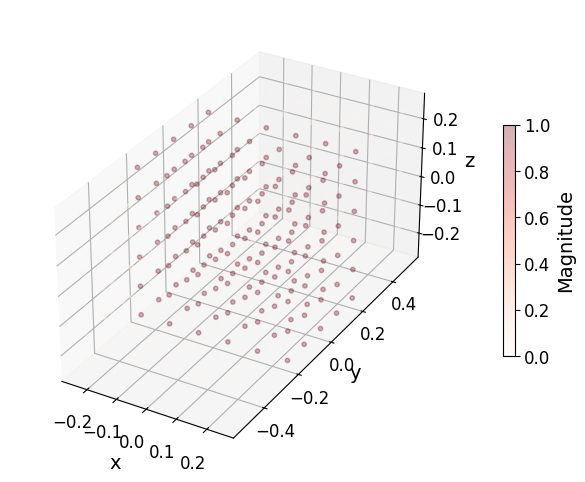

Total Activated Nodes: [180.]
time: 676 ms (started: 2026-05-21 17:20:31 +00:00)


In [20]:
def NN_correction_activation ( region_function , val ):
  NN_actv  =  tf.sparse.sparse_dense_matmul(region_function, val)
  NN_actv  =  np.float64( np.array(NN_actv / (NN_actv + 1e-16)) )   # normalize
  return NN_actv

# Currently activation is manual and fixed
# Activated the nodes whose supports covering the gauss points within a radius of r_ref
def manual_reference(x_center, r_ref1, r_ref2):
    # 1. Calculate the 3D distance from each cell center to the reference center
    # Shape of X_cell should be (N, 3)
    dx = X_cell[:, 0] - x_center[0]
    dy = X_cell[:, 1] - x_center[1]
    dz = X_cell[:, 2] - x_center[2]

    r = np.sqrt(dx**2 + dy**2 + dz**2)

    # 2. Create masks for the inner and outer boundaries
    # This returns an array of Booleans (True/False)
    mask = (dy > r_ref1) & (dy < r_ref2)

    # 3. Convert Booleans to floats (1.0 for True, 0.0 for False)
    v = tf.cast(mask, dtype=tf.float64).numpy()

    # 4. Reshape to (N, 1) to match your original function's output format
    return v.reshape(-1,1)

NN_actv = NN_correction_activation ( region_cell  ,  manual_reference( [0., 0., 0.] , -0.05, 0.05 ) )

is_activated = NN_actv

Plot_3D_Results(X_node[:,0], X_node[:,1], X_node[:,2], np.transpose(is_activated)[0], figsize=(8, 6), cmap='Reds')

# Plot_3D_Slice(X_node[:,0], X_node[:,1], X_node[:,2], np.transpose(is_activated)[0], z_slice=0., tolerance=0.001)

print(f"Total Activated Nodes: {sum(is_activated)}")

Starting RK Optimization...
Epoch 1 | Loss: 2.188569e-01
Epoch 101 | Loss: 1.632949e-01
Epoch 201 | Loss: 1.258105e-01
Epoch 301 | Loss: 1.006022e-01
Epoch 401 | Loss: 8.347758e-02
Epoch 501 | Loss: 7.160034e-02
Epoch 601 | Loss: 6.319683e-02
Epoch 701 | Loss: 5.716059e-02
Epoch 801 | Loss: 5.279121e-02
Epoch 901 | Loss: 4.963433e-02
Epoch 1001 | Loss: 4.737956e-02
Epoch 1101 | Loss: 4.579966e-02
Epoch 1201 | Loss: 4.471904e-02
Epoch 1301 | Loss: 4.399946e-02
Epoch 1401 | Loss: 4.353325e-02
Epoch 1501 | Loss: 4.323916e-02
Epoch 1601 | Loss: 4.305804e-02
Epoch 1701 | Loss: 4.294874e-02
Epoch 1801 | Loss: 4.288364e-02
Epoch 1901 | Loss: 4.284511e-02
Epoch 2001 | Loss: 4.282212e-02
Epoch 2101 | Loss: 4.280819e-02
Epoch 2201 | Loss: 4.279950e-02
Epoch 2301 | Loss: 4.279389e-02
Epoch 2401 | Loss: 4.279014e-02
Epoch 2501 | Loss: 4.278755e-02
Epoch 2601 | Loss: 4.278581e-02
Epoch 2701 | Loss: 4.278441e-02
Epoch 2801 | Loss: 4.278345e-02
Epoch 2901 | Loss: 4.278279e-02
Epoch 3001 | Loss: 4.278

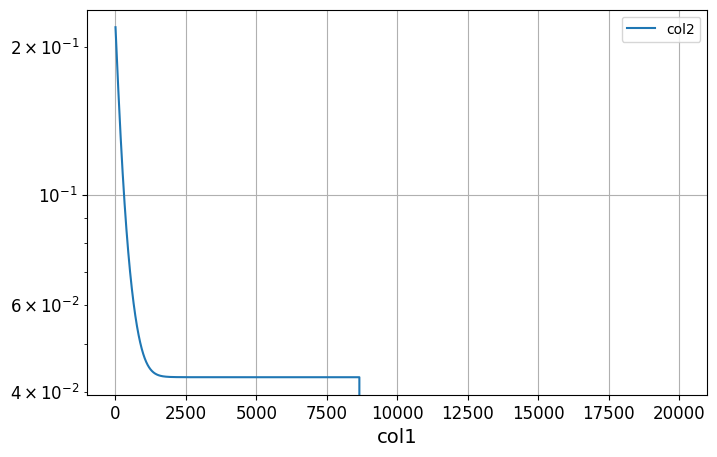

time: 29.7 s (started: 2026-05-21 17:20:38 +00:00)


In [21]:
#@title Adam: update RK coefficients only first (IF precomputed and inputed for the initial values for RK coefficients, no need to run this)

num_epochs = 20000
err_sv = tf.Variable(tf.zeros([num_epochs], dtype=tf.float64))
total_e    = tf.Variable(0, dtype=tf.int64)
learning_rate = 1e-3
optimizer1 = tf.keras.optimizers.Adam(learning_rate=learning_rate, epsilon=1e-6)

# Early stopping parameters
prev_loss = float('inf')
early_stopping_counter = 0
early_stopping_threshold = 1e-12

print("Starting RK Optimization...")

with tf.device('gpu:0'):
  for epoch in range(num_epochs):
    # each training epoch runs @tf.function graph
    loss_t = adam_RK(dx_int, dy_int, dz_int, total_e, optimizer1)
    loss_f = tf.cast(loss_t, err_sv.dtype)  # match dtype

    # store & print live
    err_sv.scatter_nd_update(indices=[[epoch]], updates=[loss_f])

    # early stopping check
    if epoch > 0:
      change_in_loss = abs(prev_loss-loss_f.numpy())
      if change_in_loss < early_stopping_threshold:
        early_stopping_counter += 1
      else:
        early_stopping_counter = 0
      if early_stopping_counter >= 5:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        print(f"Change in loss ({change_in_loss:.2e}) < Threshold ({early_stopping_threshold:.2e}) for 5 steps.")
        break

    prev_loss = loss_f.numpy()

    if epoch % 100 == 0:
      print(f"Epoch {int(total_e.numpy())} | Loss: {loss_f.numpy():.6e}")

print(" ")
print("Optimization Finished.")

d = {'col1': np.linspace(1,err_sv.numpy().shape[0],err_sv.numpy().shape[0]), 'col2': err_sv.numpy()}
pd.DataFrame(d).plot(x='col1',y='col2',figsize=(8,5), logy=True)
plt.grid(True)
plt.show()

 RK displacements =========================


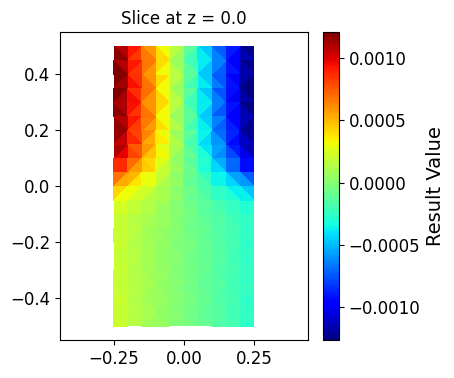

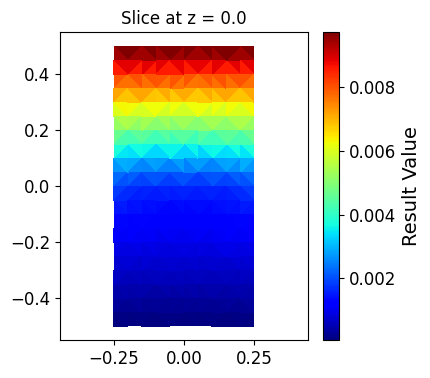

RK normal strains =========================


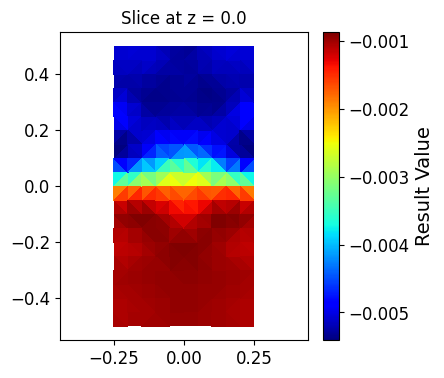

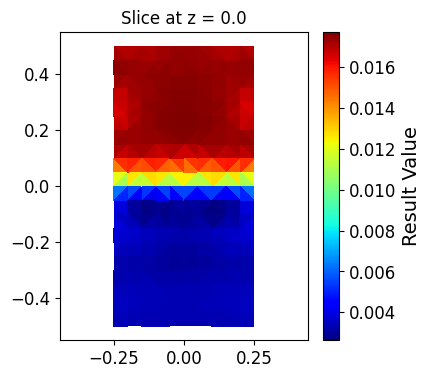

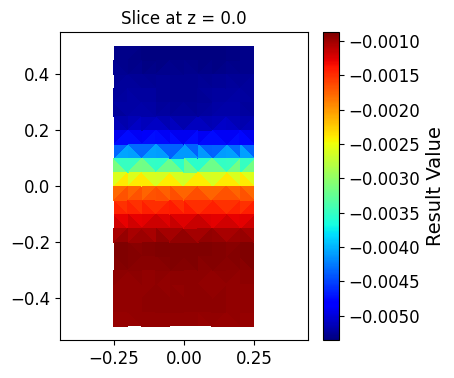

RK normal stresses =========================


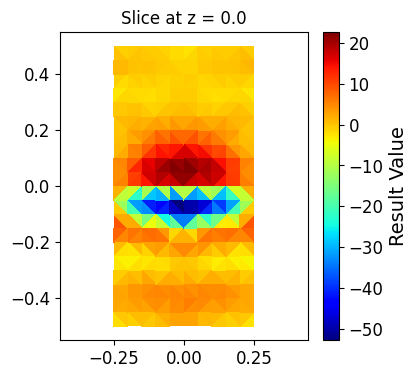

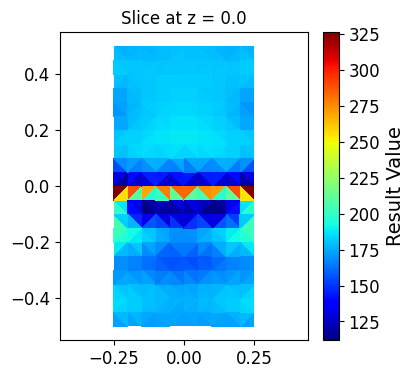

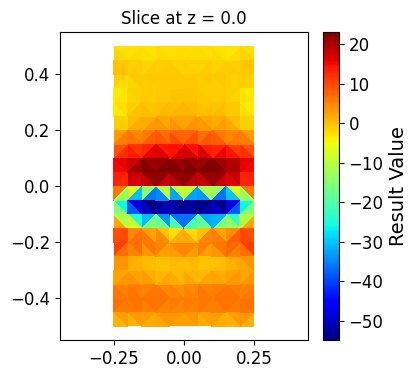

time: 1.3 s (started: 2026-05-21 17:21:58 +00:00)


In [23]:
#@title Plot displacement and stress
print(" RK displacements =========================")
ux   =   RK_approximation(SHP_cell, d_scaling*dx_int, use_CVC=1, CVC=CVC_int_x, use_ebc=1, d_ebc=dx_ebc, CVC_ebc=CVC_ebc_x)
uy   =   RK_approximation(SHP_cell, d_scaling*dy_int, use_CVC=1, CVC=CVC_int_y, use_ebc=1, d_ebc=dy_ebc, CVC_ebc=CVC_ebc_y)
uz   =   RK_approximation(SHP_cell, d_scaling*dz_int, use_CVC=1, CVC=CVC_int_z, use_ebc=1, d_ebc=dz_ebc, CVC_ebc=CVC_ebc_z)

Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(ux)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uy)[0], z_slice=0., tolerance=0.001)

print("RK normal strains =========================")

# strains (RK)
[e11, e22, e33, g12, g23, g13] = get_strain_RK(SHP_smooth, d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int, dx_ebc, dy_ebc,dz_ebc,
                  CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y, CVC_ebc_z, P1_smooth, P2_smooth, P3_smooth)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e33)[0], z_slice=0., tolerance=0.001)

print("RK normal stresses =========================")

# stresses (RK)
[s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s33)[0], z_slice=0., tolerance=0.001)

In [24]:
best_loss = tf.Variable(float('inf'), dtype=tf.float64)

# Create shadow variables for RK/NN coefficients
best_dx_int = tf.Variable(dx_int.read_value())
best_dy_int = tf.Variable(dy_int.read_value())
best_dz_int = tf.Variable(dz_int.read_value())
best_dx_NN  = tf.Variable(dx_NN.read_value())
best_dy_NN  = tf.Variable(dy_NN.read_value())
best_dz_NN  = tf.Variable(dz_NN.read_value())
best_model_weights = [w.numpy() for w in model_NC.trainable_weights]

time: 13.4 ms (started: 2026-05-21 17:22:15 +00:00)


Starting Adaptive NN-RK Optimization...
Epoch 0: total Loss = 4.278047e-02
Epoch 100: total Loss = 4.257860e-02
Epoch 200: total Loss = 4.240557e-02
Epoch 300: total Loss = 4.218905e-02
Epoch 400: total Loss = 4.211830e-02
Epoch 500: total Loss = 4.210700e-02
Epoch 600: total Loss = 4.210099e-02
Epoch 700: total Loss = 4.209768e-02
Epoch 800: total Loss = 4.209509e-02
Epoch 900: total Loss = 4.209279e-02
Epoch 1000: total Loss = 4.209071e-02
Epoch 1100: total Loss = 4.208872e-02
Epoch 1200: total Loss = 4.208681e-02
Epoch 1300: total Loss = 4.208496e-02
Epoch 1400: total Loss = 4.208320e-02
Epoch 1500: total Loss = 4.208160e-02
Epoch 1600: total Loss = 4.208007e-02
Epoch 1700: total Loss = 4.207920e-02
Epoch 1800: total Loss = 4.207668e-02
Epoch 1900: total Loss = 4.207509e-02
Epoch 2000: total Loss = 4.207347e-02
Epoch 2100: total Loss = 4.207185e-02
Epoch 2200: total Loss = 4.207008e-02
Epoch 2300: total Loss = 4.206831e-02
Epoch 2400: total Loss = 4.206643e-02
Epoch 2500: total Loss

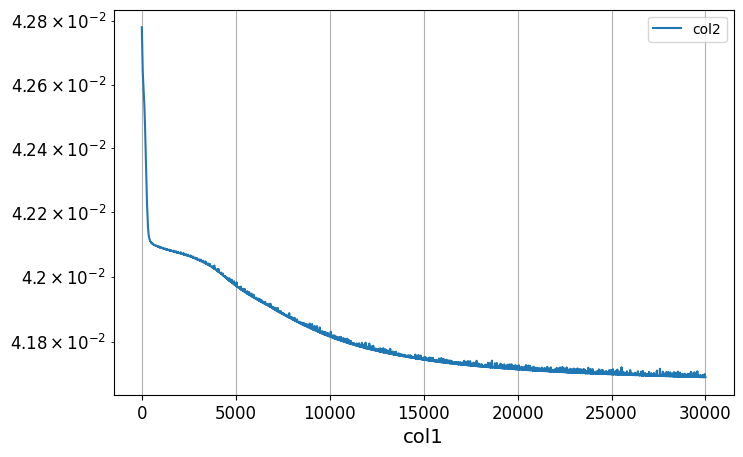

time: 4min 22s (started: 2026-05-21 17:22:20 +00:00)


In [25]:
#@title Adam: update all coefficients
# is_activated_n = np.copy(is_activated) # Initialize "previous" state

num_epochs = 30000
# num_ep_update = 10000
# total_e = tf.Variable(0, dtype=tf.int64) # comment this, if alreay ran the RK parameter optimziation loop
total_e.assign(0)
err_svv = tf.Variable(tf.zeros([num_epochs], dtype=tf.float64))

prev_loss = float('inf')
early_stopping_counter = 0
early_stopping_threshold = 1e-11
learning_rate = 1e-4
optimizer2 = tf.keras.optimizers.Adam(learning_rate=learning_rate, epsilon=1e-6)

print("Starting Adaptive NN-RK Optimization...")
with tf.device('gpu:0'):
  for epoch in range(num_epochs):
    # if (epoch > 0) and (epoch < num_ep_update) and (epoch % 1000 == 0):
    #   print(f"\n--- [Epoch {epoch}] Updating NN Activation Mask ---")
    #   # 1. Calculate New Mask (and backup old one)
    #         # update_switch calls get_activ, which uses the CURRENT displacements to find error
    #   [is_activated_n, is_activated] = update_switch(is_activated_n, is_activated, dx_int, dy_int, dx_NN, dy_NN)
    #   print(f"activated nodes: {np.sum(is_activated)} at epoch {epoch}")
    #   [dx_int, dy_int, dx_NN, dy_NN] = update_d_by_switch(dx_int, dy_int, dx_NN, dy_NN, is_activated_n, is_activated)

    loss_t= adam_NNRK(dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN, total_e, optimizer2,
                           is_activated=is_activated)
    loss_f = tf.cast(loss_t, err_svv.dtype)  # match dtype
    # store & print live
    err_svv.scatter_nd_update(indices=[[epoch]], updates=[loss_f])

    # early stopping check
    if epoch > 100:
      change_in_loss = abs(prev_loss-loss_f.numpy())
      if change_in_loss < early_stopping_threshold:
        early_stopping_counter += 1
      else:
        early_stopping_counter = 0
      if early_stopping_counter >= 5:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        print(f"Change in loss ({change_in_loss:.2e}) < Threshold ({early_stopping_threshold:.2e}) for 5 steps.")
        break

    prev_loss = loss_f.numpy()
    # best snapshot
    if loss_f < best_loss:
      best_loss = loss_f
      save_epoch = epoch
      best_model_weights = [w.numpy() for w in model_NC.trainable_weights]
      best_dx_NN = dx_NN.numpy()
      best_dy_NN = dy_NN.numpy()
      best_dz_NN = dz_NN.numpy()
      best_dx_int = dx_int.numpy()
      best_dy_int = dy_int.numpy()
      best_dz_int = dz_int.numpy()

    if epoch % 100 == 0:
      print(f"Epoch {epoch}: total Loss = {loss_f:.6e}")

print("ADAM NNRK optimization finished.")
# restore best
for w, val in zip(model_NC.trainable_weights, best_model_weights):
  w.assign(val)
dx_NN.assign(best_dx_NN)
dy_NN.assign(best_dy_NN)
dz_NN.assign(best_dz_NN)
dx_int.assign(best_dx_int)
dy_int.assign(best_dy_int)
dz_int.assign(best_dz_int)

d = {'col1': np.linspace(1,err_svv.numpy().shape[0],err_svv.numpy().shape[0]), 'col2': err_svv.numpy()}
pd.DataFrame(d).plot(x='col1',y='col2',figsize=(8,5), logy=True)
plt.grid(True)
plt.show()

Total displacements =========================


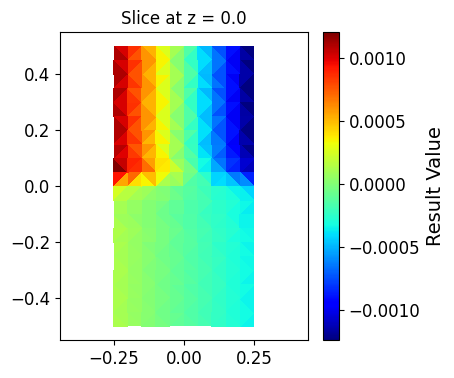

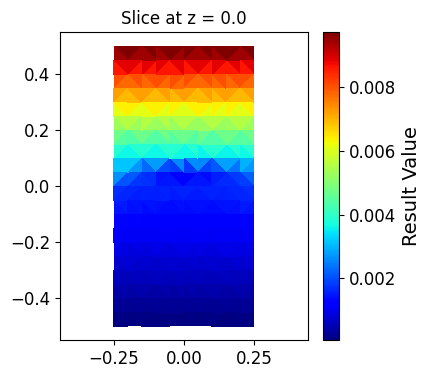

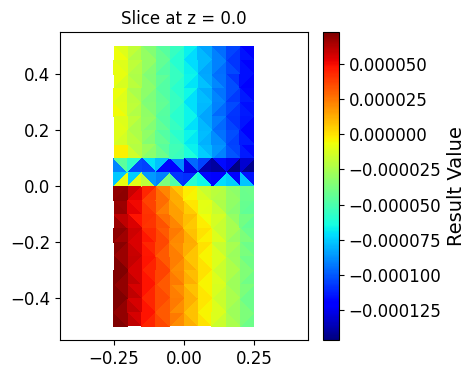

NN y displacements =========================


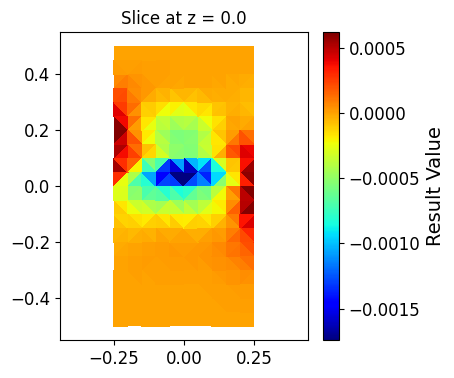

Total normal strains =========================


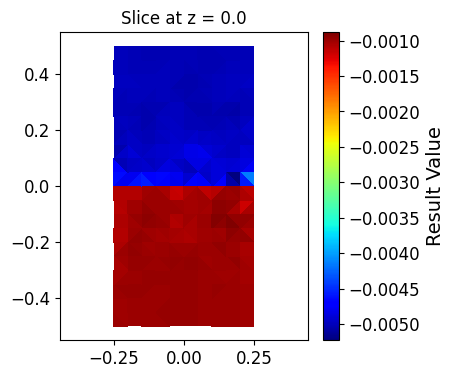

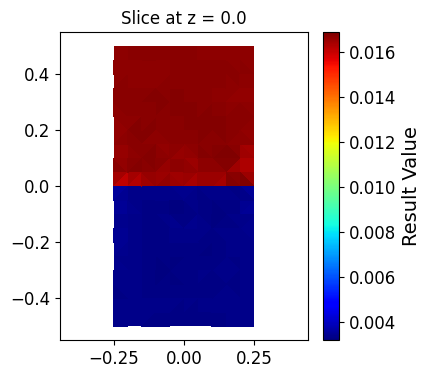

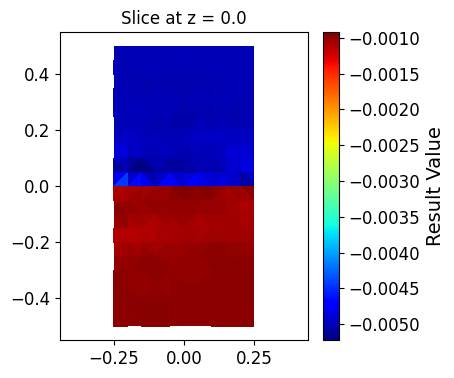

NN normal strains =========================


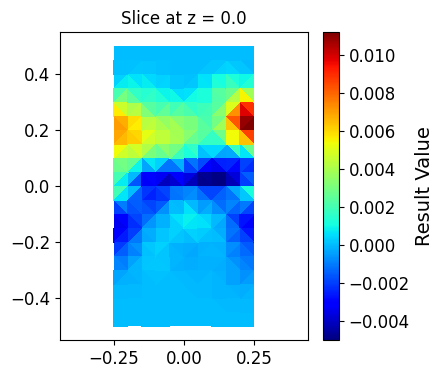

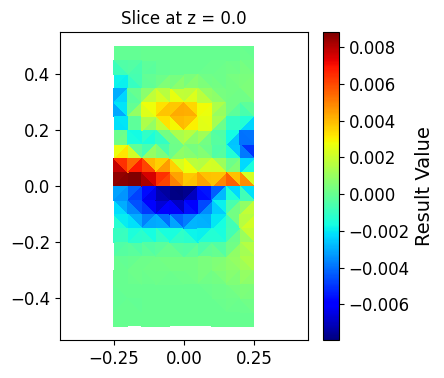

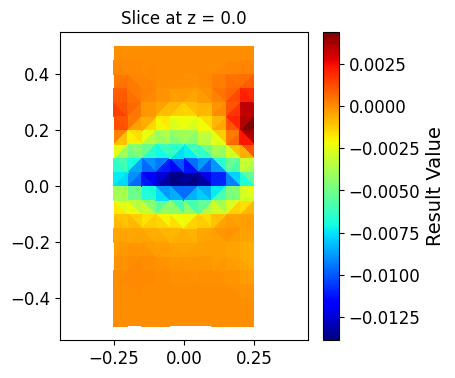

Total normal stresses =========================


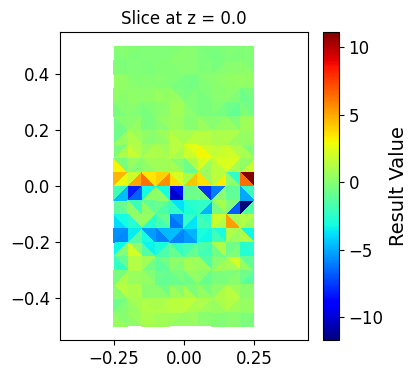

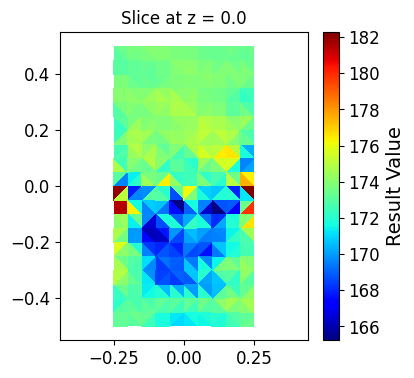

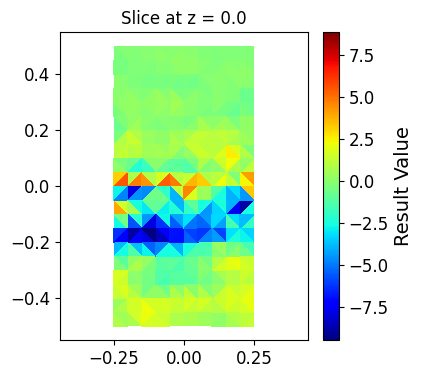

time: 2.64 s (started: 2026-05-21 17:26:43 +00:00)


In [26]:
#@title Plot displacement and stress (NNRK-ADAM)
print("Total displacements =========================")
[ux, uy, uz]   =   total_approximation(X_cell, model_NC, SHP_cell,
                         d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int, dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN,
                         d_scaling*dz_NN, CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z,
                         is_activated, sum_NC, WT, M_c)

Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(ux)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uy)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uz)[0], z_slice=0., tolerance=0.001)

print("NN y displacements =========================")


[ux_nn, uy_nn,uz_nn, _] = total_approximation_nn( X_cell, model_NC, SHP_cell,
                         d_scaling*dx_NN, d_scaling*dy_NN,d_scaling*dz_NN,
                         CVC_int_x, CVC_int_y,CVC_int_z,
                         is_activated, sum_NC, WT, M_c )

Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uy_nn)[0], z_slice=0., tolerance=0.001)
###########################

print("Total normal strains =========================")
# strains
[e11, e22, e33, g12, g23, g13] = get_strain_NNRK(X_smooth, model_NC, SHP_smooth, d_scaling*dx_int, d_scaling*dy_int,d_scaling*dz_int,
                    dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN, d_scaling*dz_NN, CVC_int_x, CVC_int_y, CVC_int_z,
                                                 CVC_ebc_x, CVC_ebc_y, CVC_ebc_z,
                    is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e33)[0], z_slice=0., tolerance=0.001)

print("NN normal strains =========================")

[e11_nn, e22_nn, e33_nn, g12_nn, g23_nn, g13_nn] = get_strain_NN(X_smooth, model_NC, SHP_smooth, d_scaling*dx_NN, d_scaling*dy_NN,d_scaling*dz_NN,
                  CVC_int_x, CVC_int_y, CVC_int_z, is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e11_nn)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e22_nn)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e33_nn)[0], z_slice=0., tolerance=0.001)
###########################

print("Total normal stresses =========================")
# stresses
[s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s33)[0], z_slice=0., tolerance=0.001)

In [27]:
#@title Write solutions
write_solution ( X_cell, ux, uy, uz, uy_nn, e11, e22, e33, g23, g13, g12, name_folder + 'results_nnrk_adam.txt')

time: 48.7 ms (started: 2026-05-21 17:26:45 +00:00)


In [ ]:
zeta_out    =   model_NC(X_cell)
file_name = name_folder + 'Enrichment_cell_ADAM.txt'
np.savetxt(file_name, zeta_out)

zeta_out    =   model_NC(X_smooth)
file_name = name_folder + 'Enrichment_smooth_ADAM.txt'
np.savetxt(file_name, zeta_out)

zeta_out    =   model_NC(X_node)
file_name = name_folder + 'Enrichment_node_ADAM.txt'
np.savetxt(file_name, zeta_out)

In [ ]:
# Save each layer's weights and biases
output_dir = name_folder

for i, layer in enumerate(model_NC.layers):
    if isinstance(layer, tf.keras.layers.Dense):  # Only save Dense layers
        weights, biases = layer.get_weights()  # Extract weights and biases

        # Save weights as text file
        weight_filename = os.path.join(output_dir, f"layer_{i}_weights.txt")
        np.savetxt(weight_filename, weights, delimiter=" ")

        # Save biases as text file
        bias_filename = os.path.join(output_dir, f"layer_{i}_biases.txt")
        np.savetxt(bias_filename, biases, delimiter=" ")

print(f"Weights and biases saved in '{output_dir}' directory.")

In [28]:
#@title LBFGS: update all coefficients
n_sub_step = 1
iter_per_step = 2000

for i_sub_step in range(n_sub_step):
  func = function_factory_NNRK()

  # convert initial model parameters to a 1D tf.Tensor
  init_params = tf.dynamic_stitch(func.idx, [dx_int, dy_int, dz_int, dx_NN, dy_NN, dz_NN] + model_NC.trainable_variables)

  # train the model with L-BFGS solver
  with tf.device('gpu:0'):
    tic = time.time()
    results = tfp.optimizer.lbfgs_minimize(
        value_and_gradients_function=func, initial_position=init_params, max_iterations=iter_per_step, max_line_search_iterations=100, num_correction_pairs=20)
    toc = time.time()

  print(' ')
  print('L-BFGS Done! ', toc-tic, ' (s)')
  print('Converged:', results.converged.numpy())
  # print('Final Loss:', results.objective_value.numpy())

  # after training, the final optimized parameters are still in results.position
  # so we have to manually put them back to the model
  func.assign_new_model_parameters(results.position)

  save_weights(name_folder_final+"LBFGS/", "NNRK")

Iter: 100 loss: 0.041690238538795506
Iter: 200 loss: 0.041690099500795712
Iter: 300 loss: 0.041689870400539911
Iter: 400 loss: 0.041689587121349715
Iter: 500 loss: 0.041689299438800363
Iter: 600 loss: 0.04168898959207451
Iter: 700 loss: 0.041688646397882695
Iter: 800 loss: 0.041688371426306964
Iter: 900 loss: 0.041688025477520152
Iter: 1000 loss: 0.041687747530401033
Iter: 1100 loss: 0.041687441421706793
Iter: 1200 loss: 0.041687129033294253
Iter: 1300 loss: 0.041686841778248607
Iter: 1400 loss: 0.041686578620414104
Iter: 1500 loss: 0.041686235283280179
Iter: 1600 loss: 0.041685951415640257
Iter: 1700 loss: 0.0416856606587136
Iter: 1800 loss: 0.041685382998158861
Iter: 1900 loss: 0.041685113420813651
Iter: 2000 loss: 0.041684870096487914
Iter: 2100 loss: 0.041684612647567808
Iter: 2200 loss: 0.041684358368462682
Iter: 2300 loss: 0.041684115944281543
Iter: 2400 loss: 0.0416838707548073
Iter: 2500 loss: 0.041683624856576895
Iter: 2600 loss: 0.041683407595098441
Iter: 2700 loss: 0.0416831

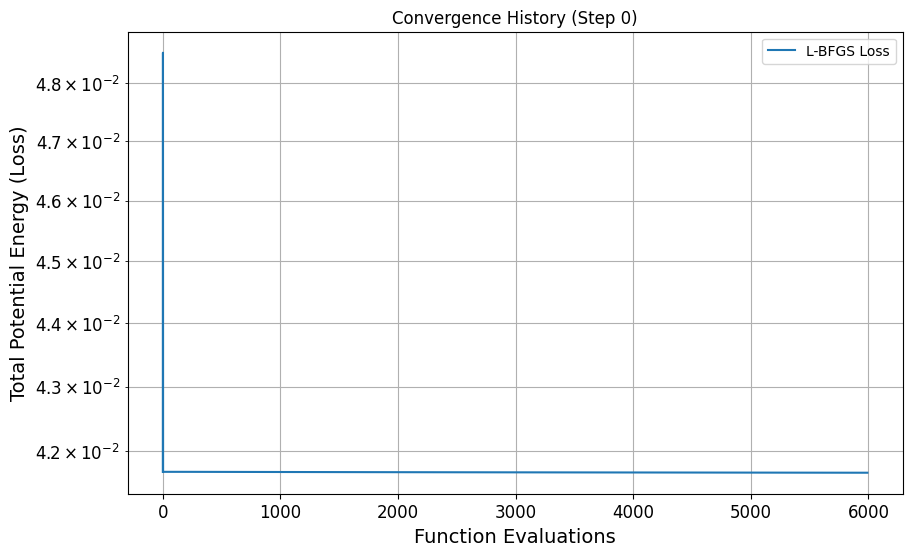

time: 446 ms (started: 2026-05-21 17:31:22 +00:00)


In [29]:
# ==========================================
# PLOT LBFGS LOSS HISTORY
# ==========================================
# func.history is a list of tensors, convert to numpy array
loss_history = np.array([x.numpy() for x in func.history])

plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='L-BFGS Loss')
plt.yscale('log') # Log scale is usually better for L-BFGS convergence plots
plt.xlabel('Function Evaluations')
plt.ylabel('Total Potential Energy (Loss)')
plt.title(f'Convergence History (Step {i_sub_step})')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

Total displacements =========================


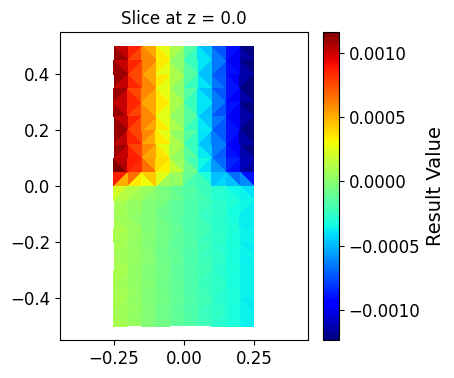

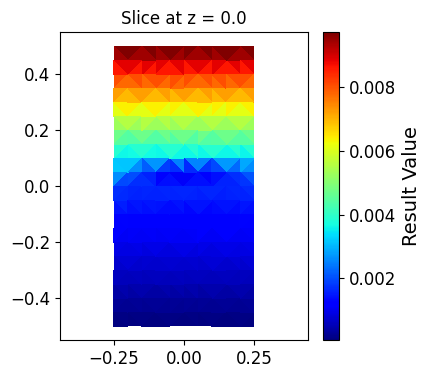

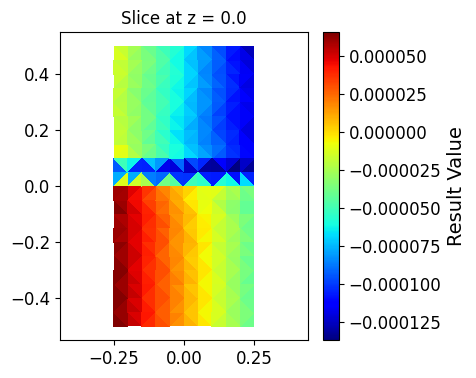

NN y displacements =========================


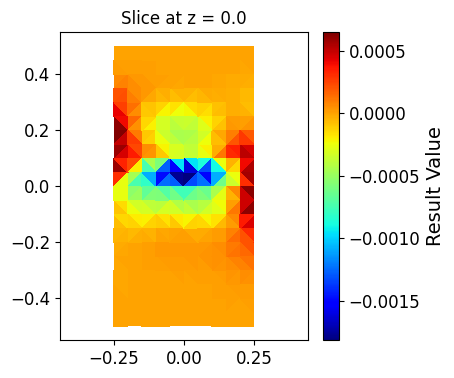

Total normal strains =========================


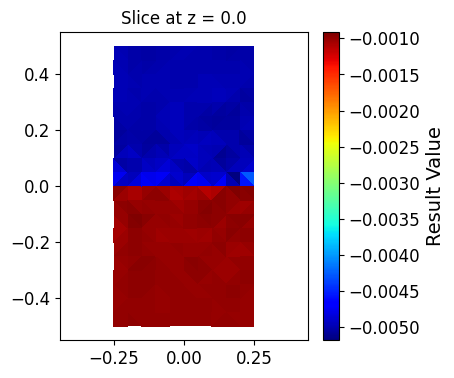

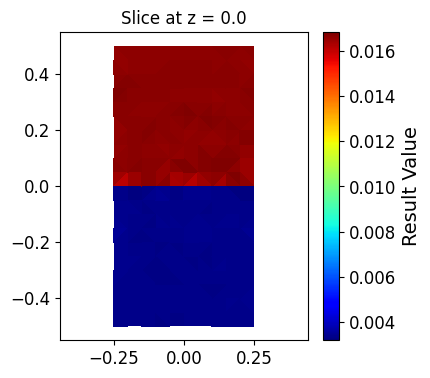

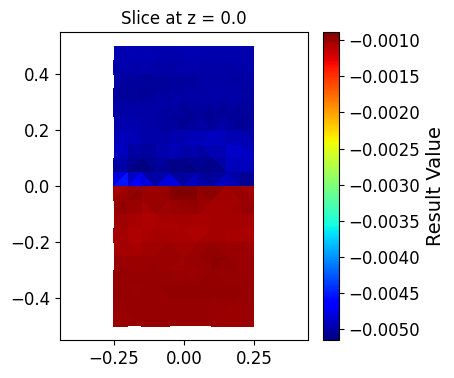

NN normal strains =========================


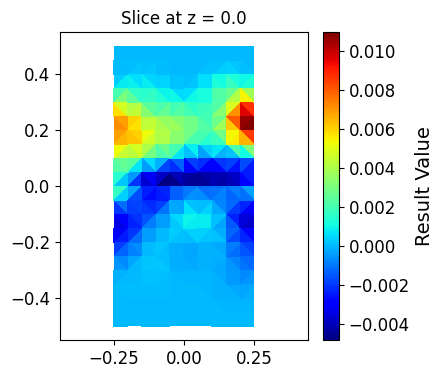

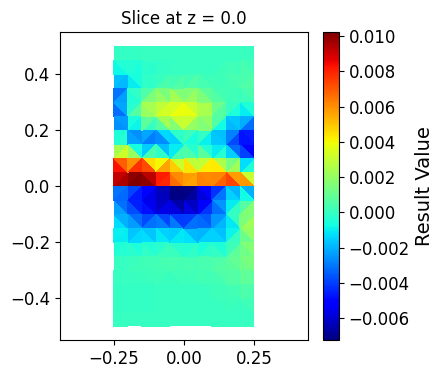

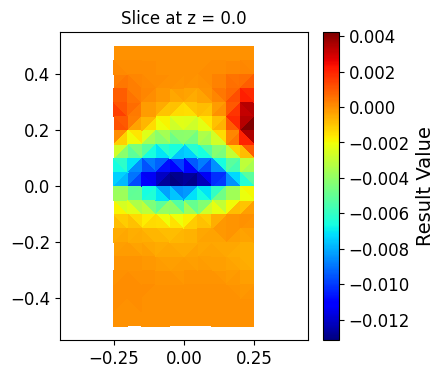

Total normal stress =========================


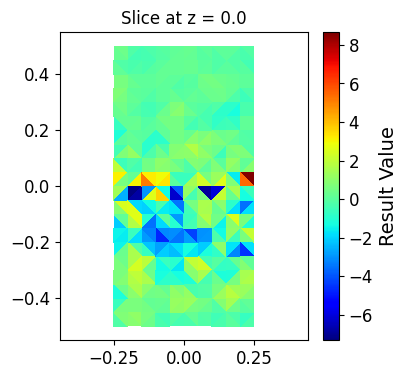

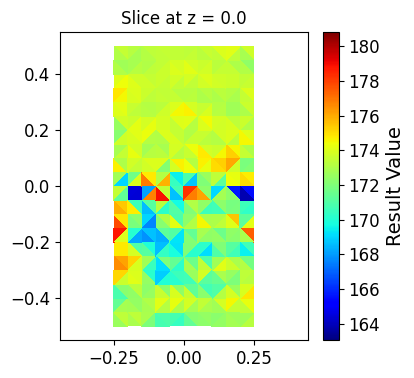

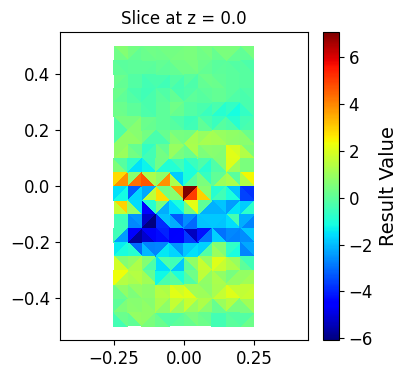

time: 2.12 s (started: 2026-05-21 17:31:23 +00:00)


In [30]:
#@title Plot displacement and stress (NNRK-LBFGS)
print("Total displacements =========================")
[ux, uy, uz]   =   total_approximation(X_cell, model_NC, SHP_cell,
                         d_scaling*dx_int, d_scaling*dy_int, d_scaling*dz_int, dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN,
                         d_scaling*dz_NN, CVC_int_x, CVC_int_y, CVC_int_z, CVC_ebc_x, CVC_ebc_y,CVC_ebc_z,
                         is_activated, sum_NC, WT, M_c)

Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(ux)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uy)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uz)[0], z_slice=0., tolerance=0.001)

print("NN y displacements =========================")


[ux_nn, uy_nn,uz_nn, _] = total_approximation_nn( X_cell, model_NC, SHP_cell,
                         d_scaling*dx_NN, d_scaling*dy_NN,d_scaling*dz_NN,
                         CVC_int_x, CVC_int_y,CVC_int_z,
                         is_activated, sum_NC, WT, M_c )

Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(uy_nn)[0], z_slice=0., tolerance=0.001)
###########################

print("Total normal strains =========================")
# strains
[e11, e22, e33, g12, g23, g13] = get_strain_NNRK(X_smooth, model_NC, SHP_smooth, d_scaling*dx_int, d_scaling*dy_int,d_scaling*dz_int,
                    dx_ebc, dy_ebc, dz_ebc, d_scaling*dx_NN, d_scaling*dy_NN, d_scaling*dz_NN, CVC_int_x, CVC_int_y, CVC_int_z,
                                                 CVC_ebc_x, CVC_ebc_y, CVC_ebc_z,
                    is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e33)[0], z_slice=0., tolerance=0.001)

print("NN normal strains =========================")

[e11_nn, e22_nn, e33_nn, g12_nn, g23_nn, g13_nn] = get_strain_NN(X_smooth, model_NC, SHP_smooth, d_scaling*dx_NN, d_scaling*dy_NN,d_scaling*dz_NN,
                  CVC_int_x, CVC_int_y, CVC_int_z, is_activated, sum_NC, P1_smooth, P2_smooth, P3_smooth, WT_smooth, M_s)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e11_nn)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e22_nn)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(e33_nn)[0], z_slice=0., tolerance=0.001)
###########################

print("Total normal stress =========================")
# stresses
[s11, s22, s33, s12, s23, s13] = get_stress(e11, e22, e33, g12, g23, g13, mat_mu, mat_lam)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s11)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s22)[0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],np.transpose(s33)[0], z_slice=0., tolerance=0.001)

In [31]:
#@title Write solutions
write_solution ( X_cell, ux, uy, uz, uy_nn, e11, e22, e33, g23, g13, g12, name_folder + 'results_nnrk_LBFGS.txt')

time: 47 ms (started: 2026-05-21 17:31:25 +00:00)


In [40]:
zeta_out    =   model_NC(X_cell)
file_name = name_folder + 'Enrichment_cell_LBFGS.txt'
np.savetxt(file_name, zeta_out)

zeta_out    =   model_NC(X_smooth)
file_name = name_folder + 'Enrichment_smooth_LBFGS.txt'
np.savetxt(file_name, zeta_out)

zeta_out    =   model_NC(X_node)
file_name = name_folder + 'Enrichment_node_LBFGS.txt'
np.savetxt(file_name, zeta_out)

time: 140 ms (started: 2026-05-21 17:46:01 +00:00)


In [42]:
# 2. Wrap the model evaluation inside a GradientTape
with tf.GradientTape() as tape:
    # Tell the tape to track operations on the input coordinates
    tape.watch(X_cell)

    # Evaluate the model (Shape: [NC, 5])
    zeta_out = model_NC(X_cell)

# 3. Compute the Batch Jacobian
# This computes the derivative of each output (5 bases) with respect to
# each input (3 coordinates) for every point in the batch (NC).
# Resulting shape: (NC, 5, 3)
jacobian = tape.batch_jacobian(zeta_out, X_cell)

# 4. Slice the Jacobian to get the specific directional derivatives
# jacobian[:, :, 0] means -> all points, all bases, derivative w.r.t x (0th coordinate)
dzeta_dx = jacobian[:, :, 0].numpy()  # Shape: (NC, 5)
dzeta_dy = jacobian[:, :, 1].numpy()  # Shape: (NC, 5)
dzeta_dz = jacobian[:, :, 2].numpy()  # Shape: (NC, 5)

zeta_out_np = zeta_out.numpy()

# 5. Save everything to text files
np.savetxt(name_folder + 'Enrichment_cell_LBFGS.txt', zeta_out_np)
np.savetxt(name_folder + 'final_cell_LBFGS_dx.txt', dzeta_dx)
np.savetxt(name_folder + 'final_cell_LBFGS_dy.txt', dzeta_dy)
np.savetxt(name_folder + 'final_cell_LBFGS_dz.txt', dzeta_dz)

time: 355 ms (started: 2026-05-21 17:48:41 +00:00)


In [43]:
with tf.GradientTape() as tape:
    # Tell the tape to track operations on the input coordinates
    tape.watch(X_smooth)

    # Evaluate the model (Shape: [NC, 5])
    zeta_out = model_NC(X_smooth)

# 3. Compute the Batch Jacobian
# This computes the derivative of each output (5 bases) with respect to
# each input (3 coordinates) for every point in the batch (NC).
# Resulting shape: (NC, 5, 3)
jacobian = tape.batch_jacobian(zeta_out, X_smooth)

# 4. Slice the Jacobian to get the specific directional derivatives
# jacobian[:, :, 0] means -> all points, all bases, derivative w.r.t x (0th coordinate)
dzeta_dx = jacobian[:, :, 0].numpy()  # Shape: (NC, 5)
dzeta_dy = jacobian[:, :, 1].numpy()  # Shape: (NC, 5)
dzeta_dz = jacobian[:, :, 2].numpy()  # Shape: (NC, 5)

zeta_out_np = zeta_out.numpy()

# 5. Save everything to text files
np.savetxt(name_folder + 'Enrichment_smooth_LBFGS.txt', zeta_out_np)
np.savetxt(name_folder + 'final_smooth_LBFGS_dx.txt', dzeta_dx)
np.savetxt(name_folder + 'final_smooth_LBFGS_dy.txt', dzeta_dy)
np.savetxt(name_folder + 'final_smooth_LBFGS_dz.txt', dzeta_dz)

time: 499 ms (started: 2026-05-21 17:49:58 +00:00)


In [44]:
with tf.GradientTape() as tape:
    # Tell the tape to track operations on the input coordinates
    tape.watch(X_node)

    # Evaluate the model (Shape: [NC, 5])
    zeta_out = model_NC(X_node)

# 3. Compute the Batch Jacobian
# This computes the derivative of each output (5 bases) with respect to
# each input (3 coordinates) for every point in the batch (NC).
# Resulting shape: (NC, 5, 3)
jacobian = tape.batch_jacobian(zeta_out, X_node)

# 4. Slice the Jacobian to get the specific directional derivatives
# jacobian[:, :, 0] means -> all points, all bases, derivative w.r.t x (0th coordinate)
dzeta_dx = jacobian[:, :, 0].numpy()  # Shape: (NC, 5)
dzeta_dy = jacobian[:, :, 1].numpy()  # Shape: (NC, 5)
dzeta_dz = jacobian[:, :, 2].numpy()  # Shape: (NC, 5)

zeta_out_np = zeta_out.numpy()

# 5. Save everything to text files
np.savetxt(name_folder + 'Enrichment_node_LBFGS.txt', zeta_out_np)
np.savetxt(name_folder + 'final_node_LBFGS_dx.txt', dzeta_dx)
np.savetxt(name_folder + 'final_node_LBFGS_dy.txt', dzeta_dy)
np.savetxt(name_folder + 'final_node_LBFGS_dz.txt', dzeta_dz)

time: 254 ms (started: 2026-05-21 17:50:46 +00:00)


In [35]:
# Save each layer's weights and biases
output_dir = name_folder_final

for i, layer in enumerate(model_NC.layers):
    if isinstance(layer, tf.keras.layers.Dense):  # Only save Dense layers
        weights, biases = layer.get_weights()  # Extract weights and biases

        # Save weights as text file
        weight_filename = os.path.join(output_dir, f"layer_{i}_weights.txt")
        np.savetxt(weight_filename, weights, delimiter=" ")

        # Save biases as text file
        bias_filename = os.path.join(output_dir, f"layer_{i}_biases.txt")
        np.savetxt(bias_filename, biases, delimiter=" ")

print(f"Weights and biases saved in '{output_dir}' directory.")

Weights and biases saved in 'drive/MyDrive/N-refinement/Input_3Dbimat_Node396_Cell2662/Results_40NR_4hidden_5bases/Final/' directory.
time: 132 ms (started: 2026-05-21 17:31:25 +00:00)


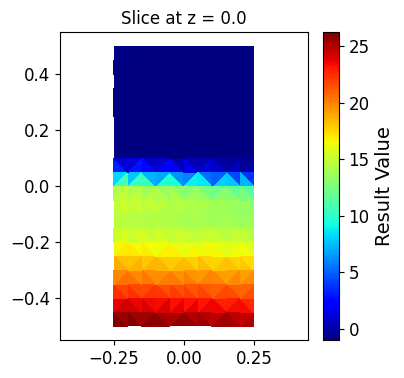

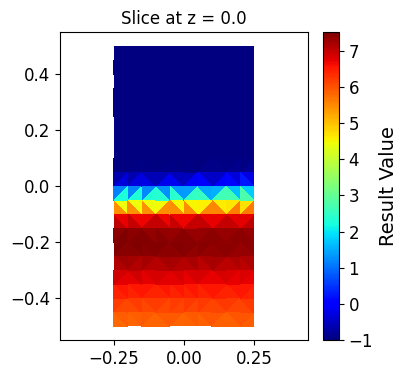

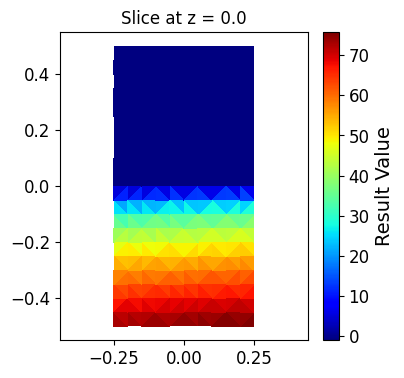

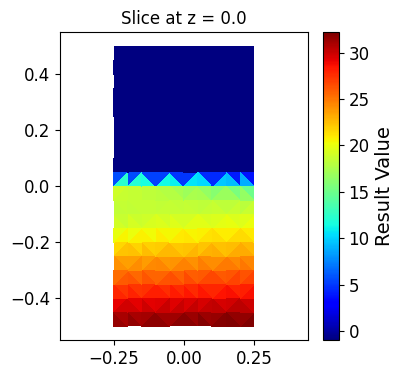

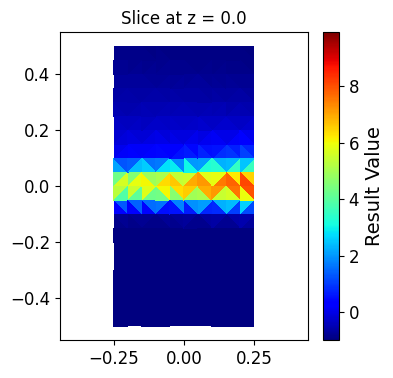

time: 824 ms (started: 2026-05-21 17:41:09 +00:00)


In [39]:
zeta_out    =   model_NC(X_cell)
# Plot_3D_Results(X_cell[:,0], X_cell[:,1], X_cell[:,2], zeta_out[:,0], figsize=(8, 6), cmap='jet')
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],zeta_out[:,0], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],zeta_out[:,1], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],zeta_out[:,2], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],zeta_out[:,3], z_slice=0., tolerance=0.001)
Plot_3D_Slice(X_cell[:,0],X_cell[:,1],X_cell[:,2],zeta_out[:,4], z_slice=0., tolerance=0.001)